In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

Zdefiniowanie funkcji celu:
$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$

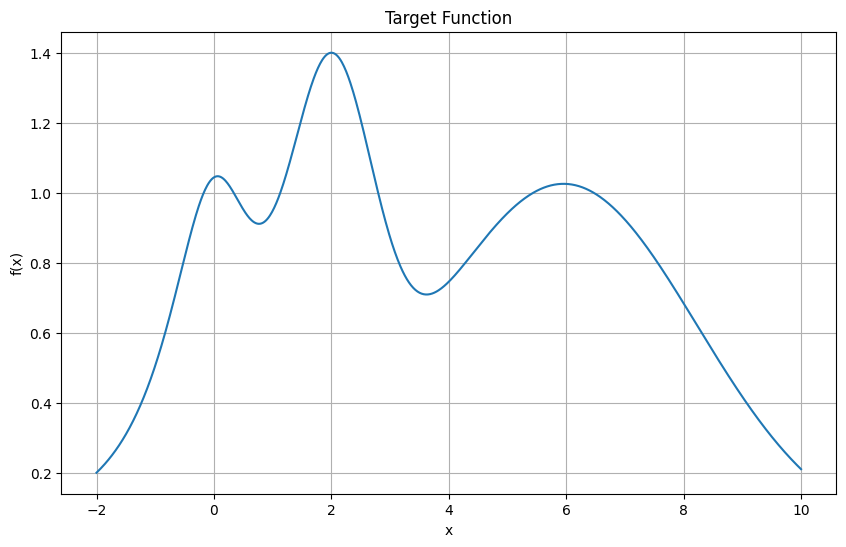

In [16]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

Zdefiniowanie funkcji wizualizacji

In [17]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=8, label="Observations", color="r"
    )
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |

Step 0: Initial random points


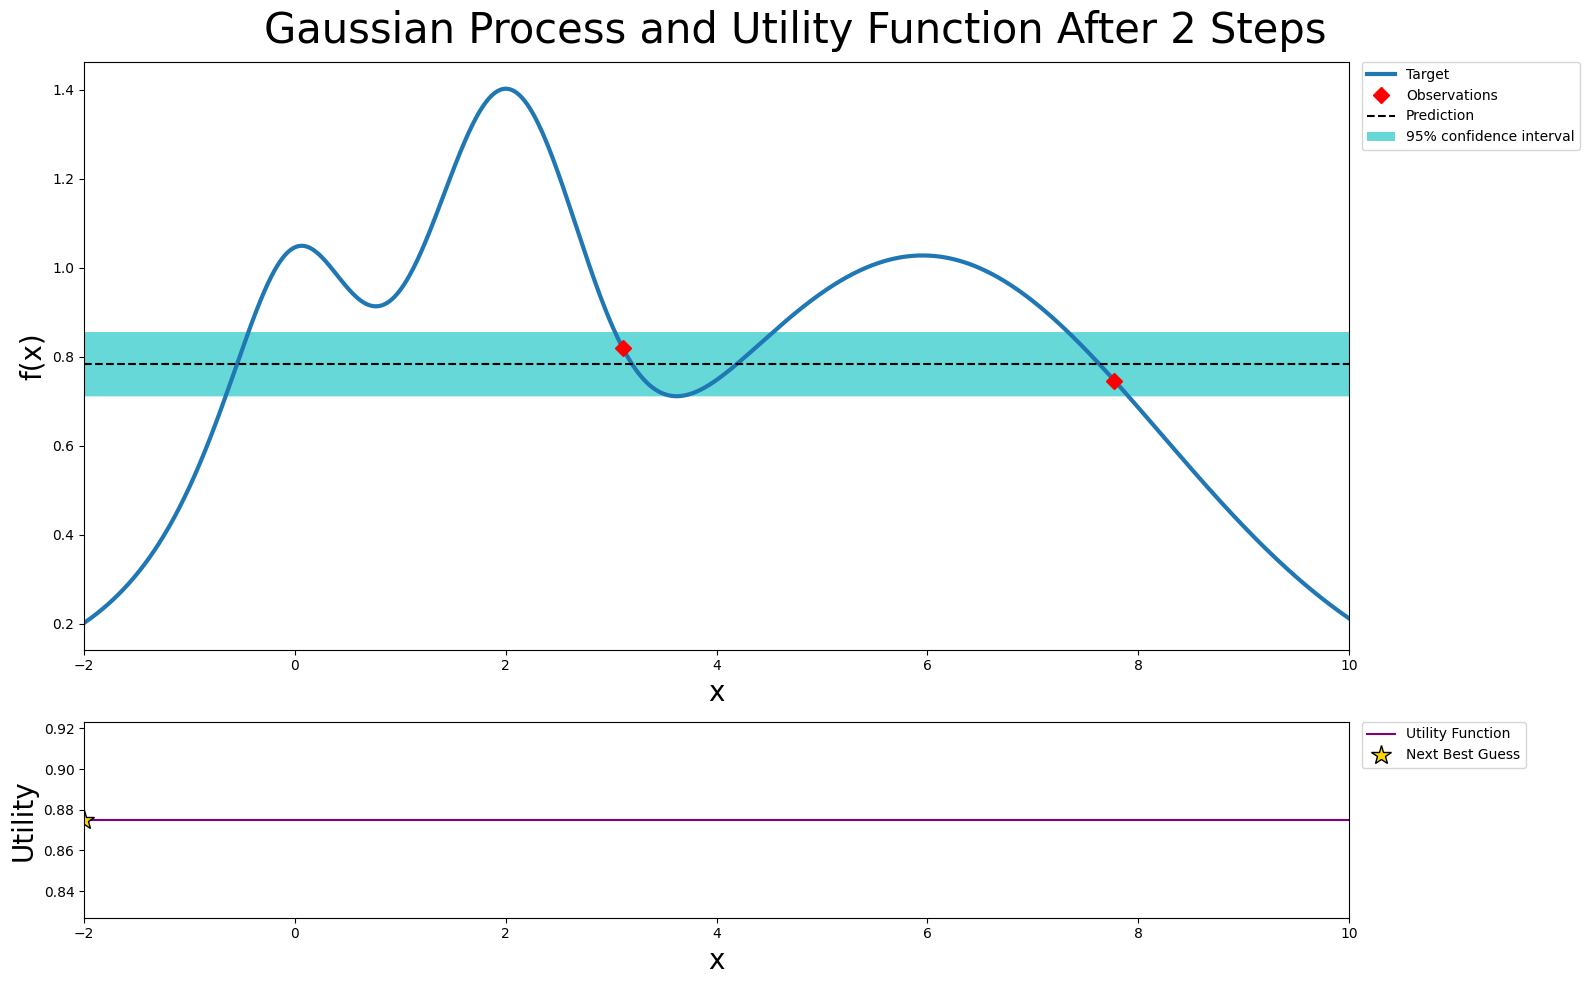

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.8190422 | 3.1102721 |

Step 1: Added a new observation


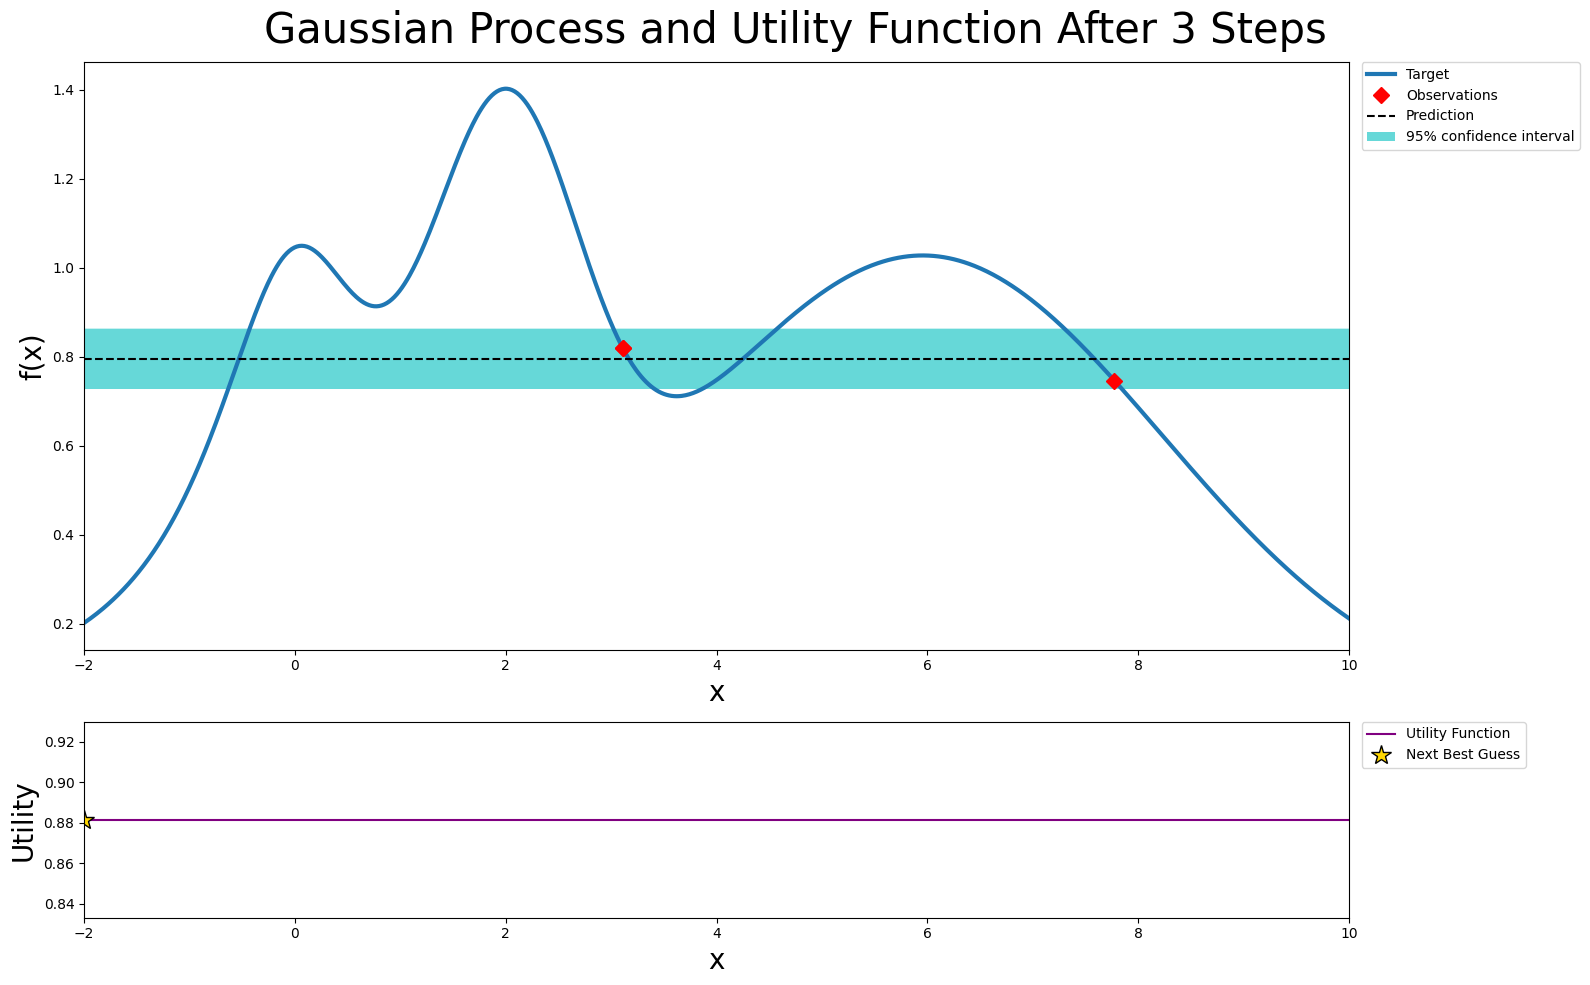

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.8943137 | 2.9649330 |

Step 2: Added a new observation


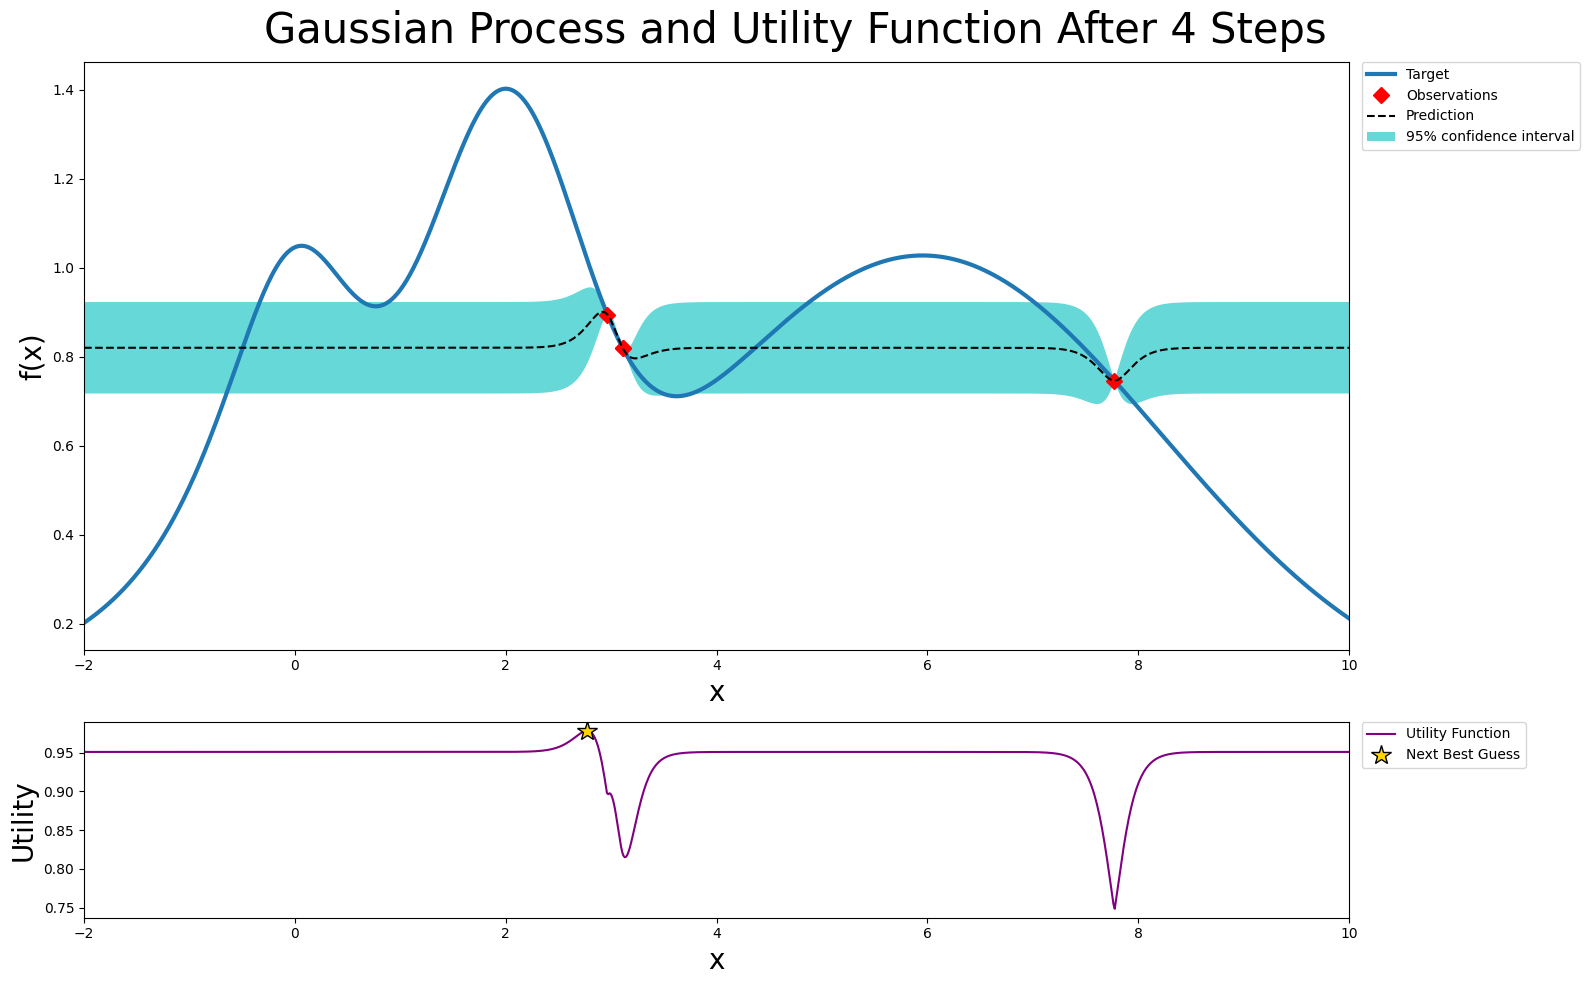

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.0188850 | 2.7720553 |

Step 3: Added a new observation


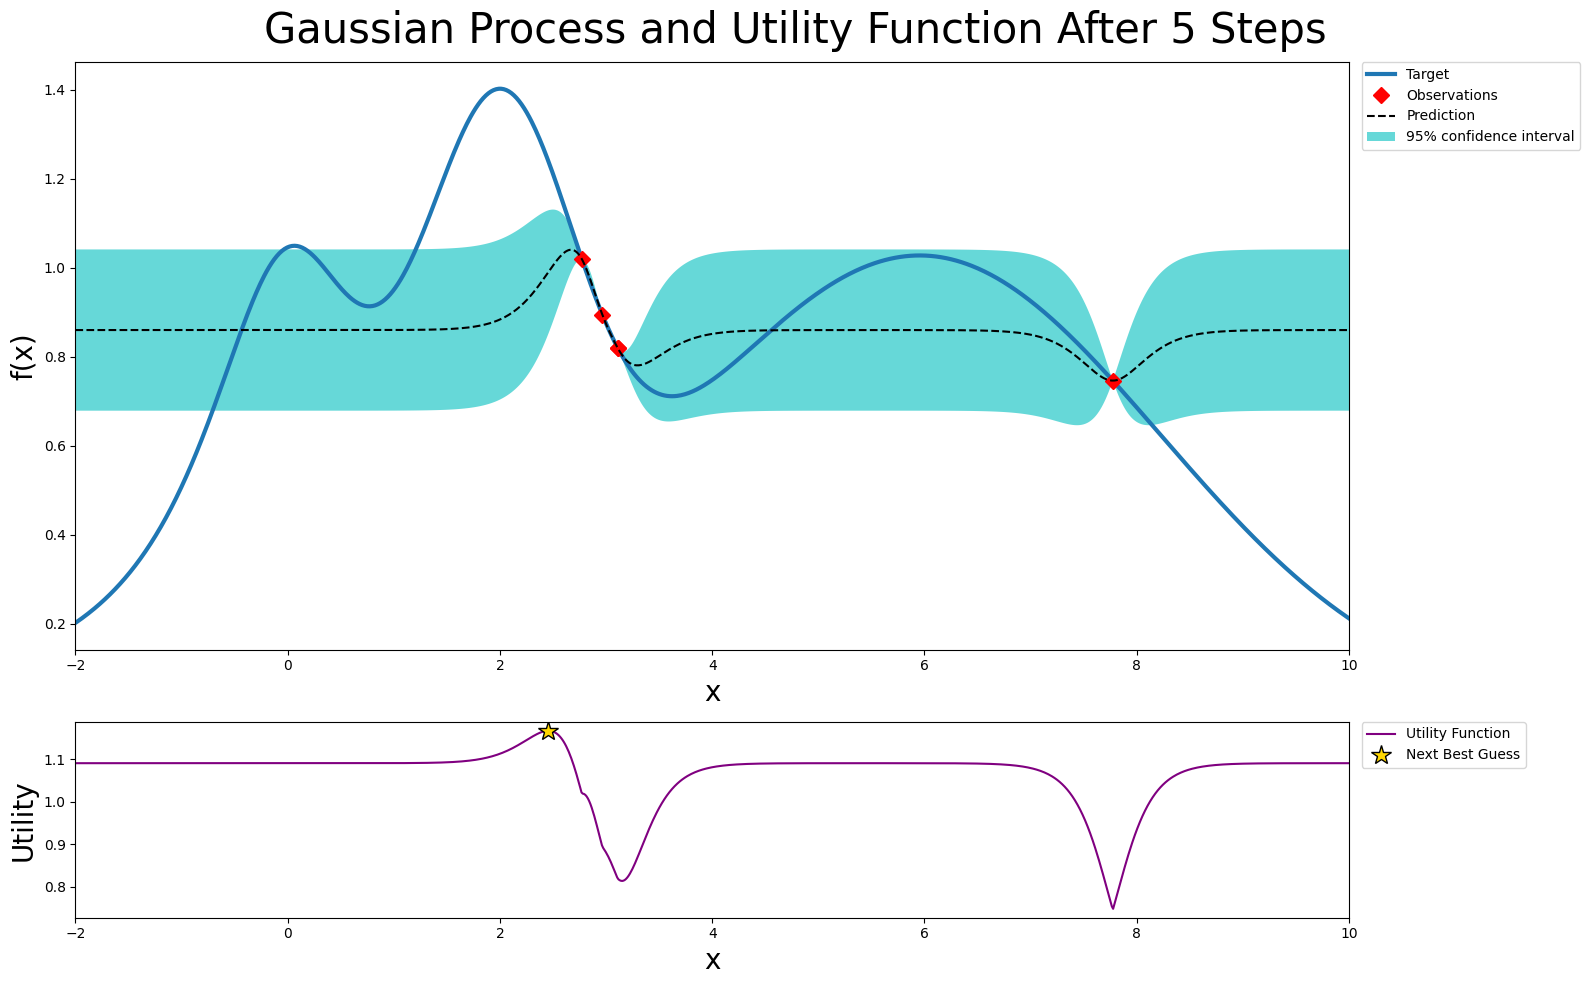

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 1.2389517 | 2.4564829 |

Step 4: Added a new observation


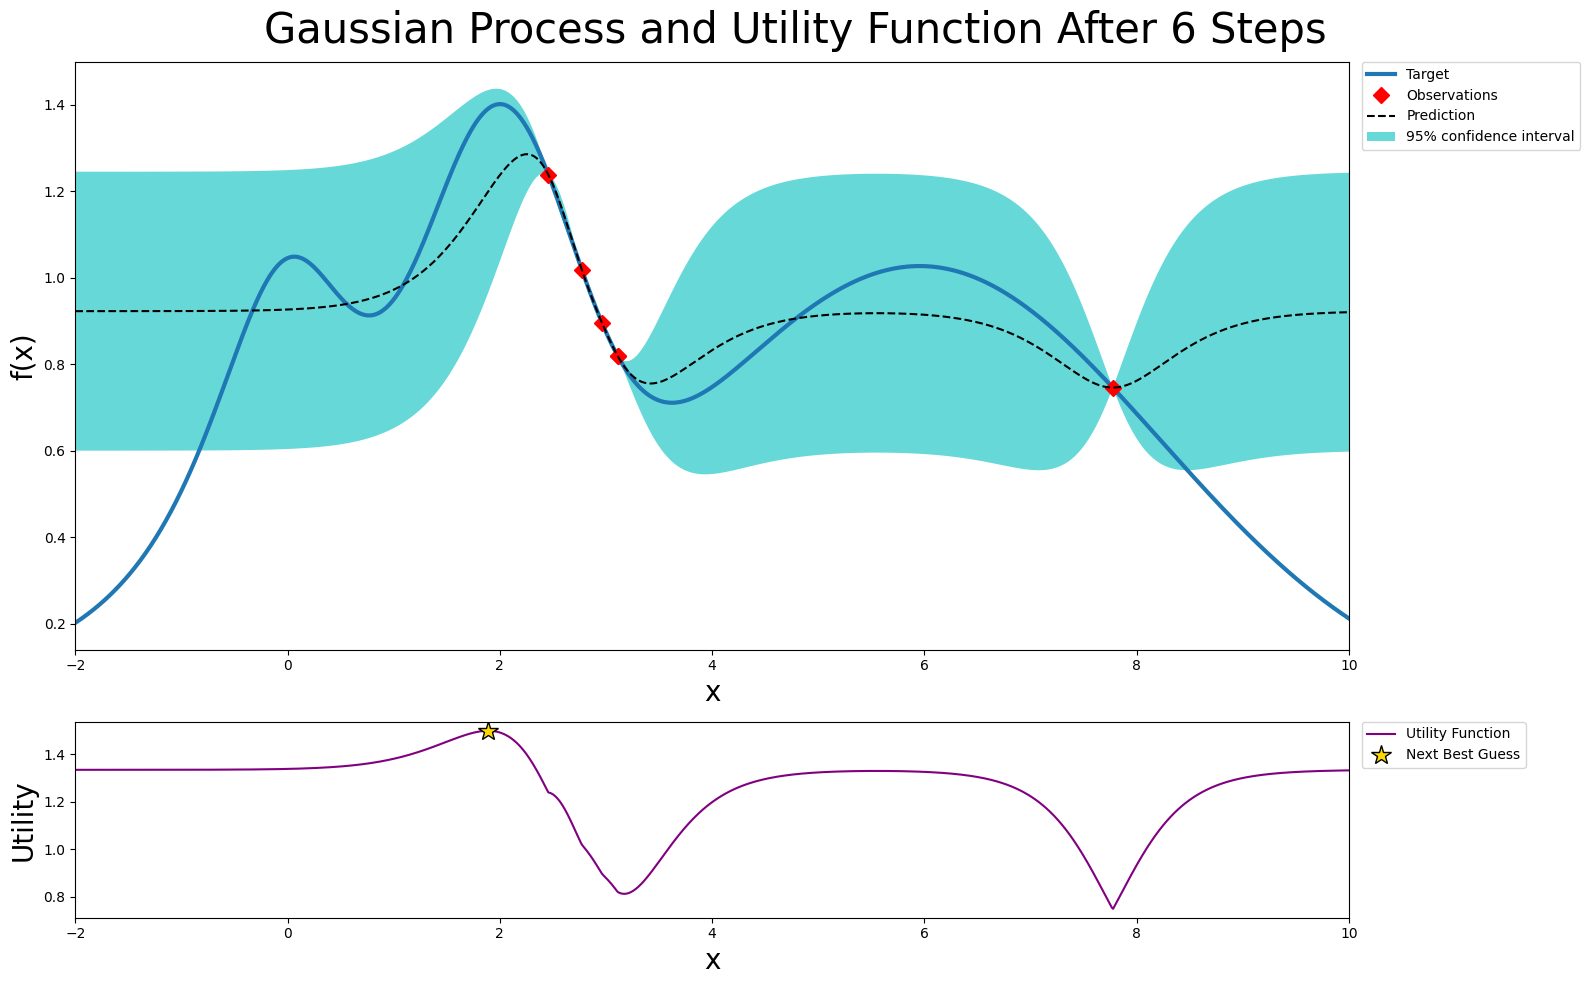

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 1.3911164 | 1.8887343 |

Step 5: Added a new observation


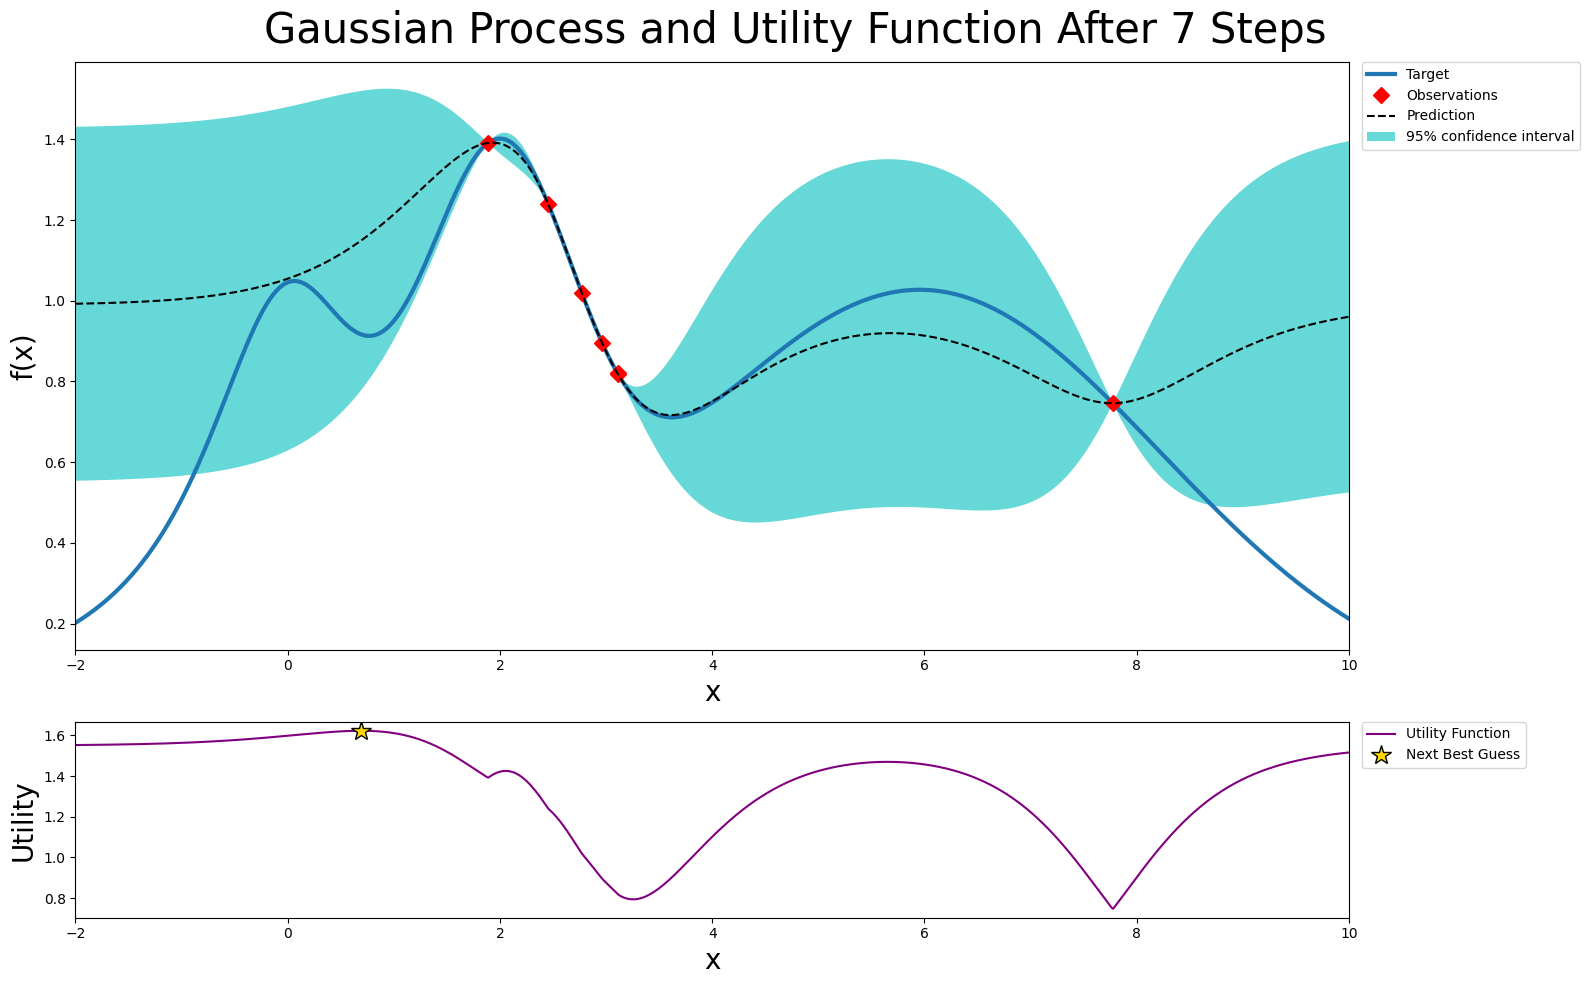


Final result:
Best target value found: 1.3911
Best input value found: x = 1.8887


In [18]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

Powyżej wyświetlana jest wizualizacja przykładowego przebiegu - ukazuje cykl działania metody

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856630 | -0.211813 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351170 | 4.9507499 |

UCB Acquisition Function Results:


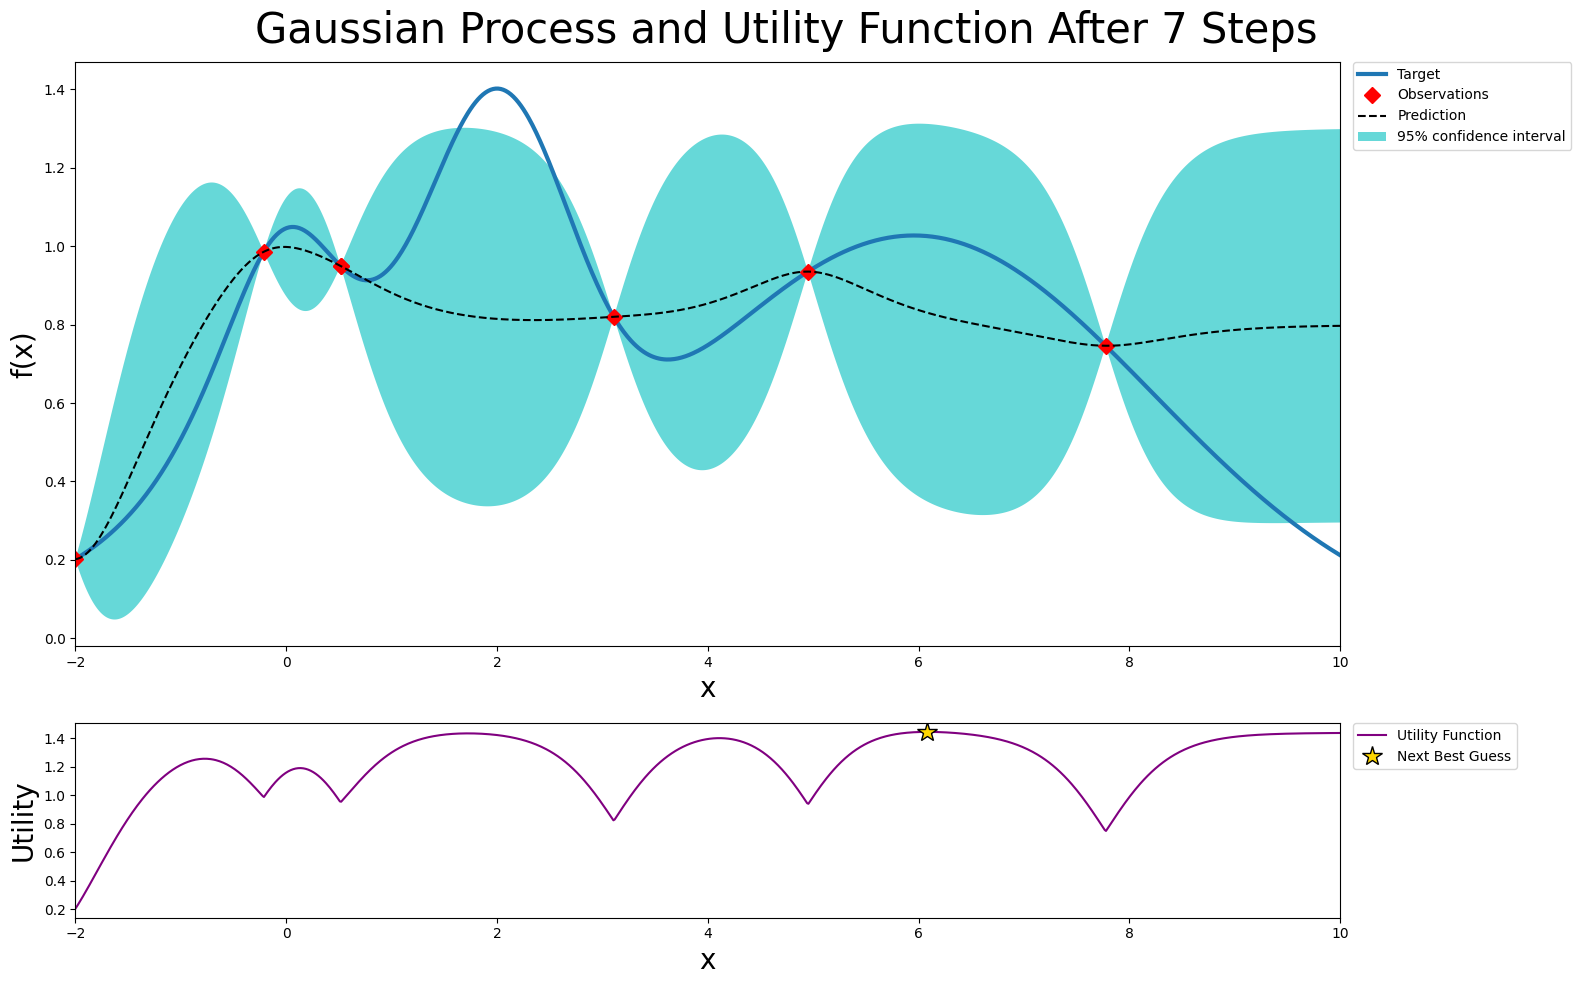

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


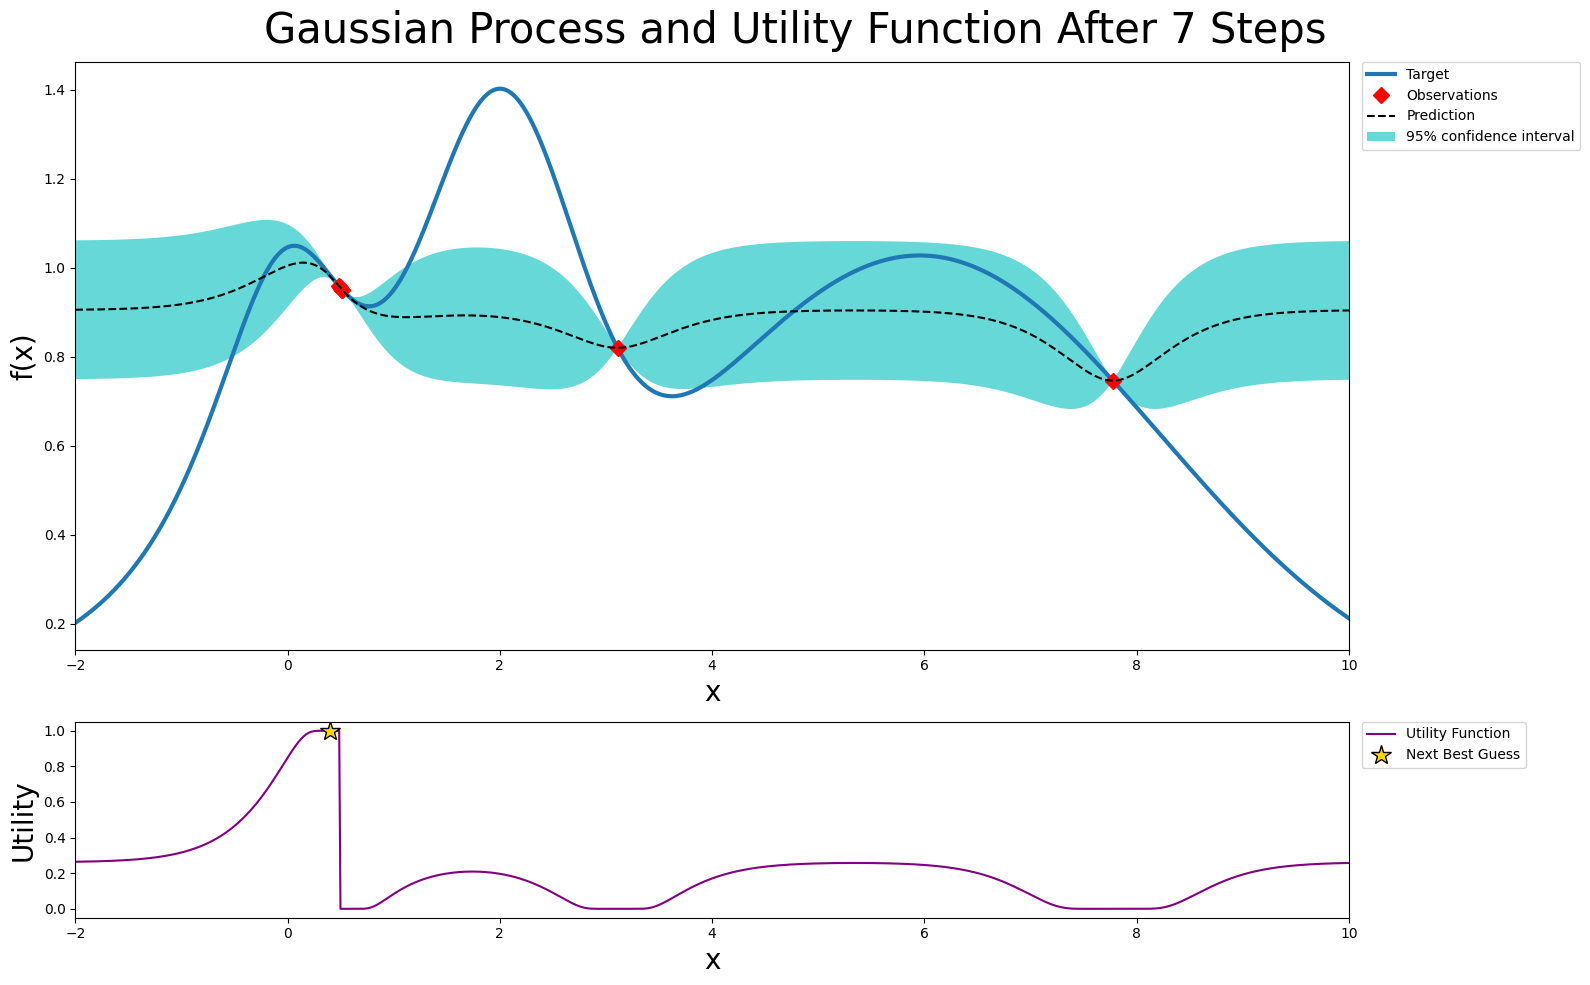

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy (Purely Exploitative) Acquisition Function Results:


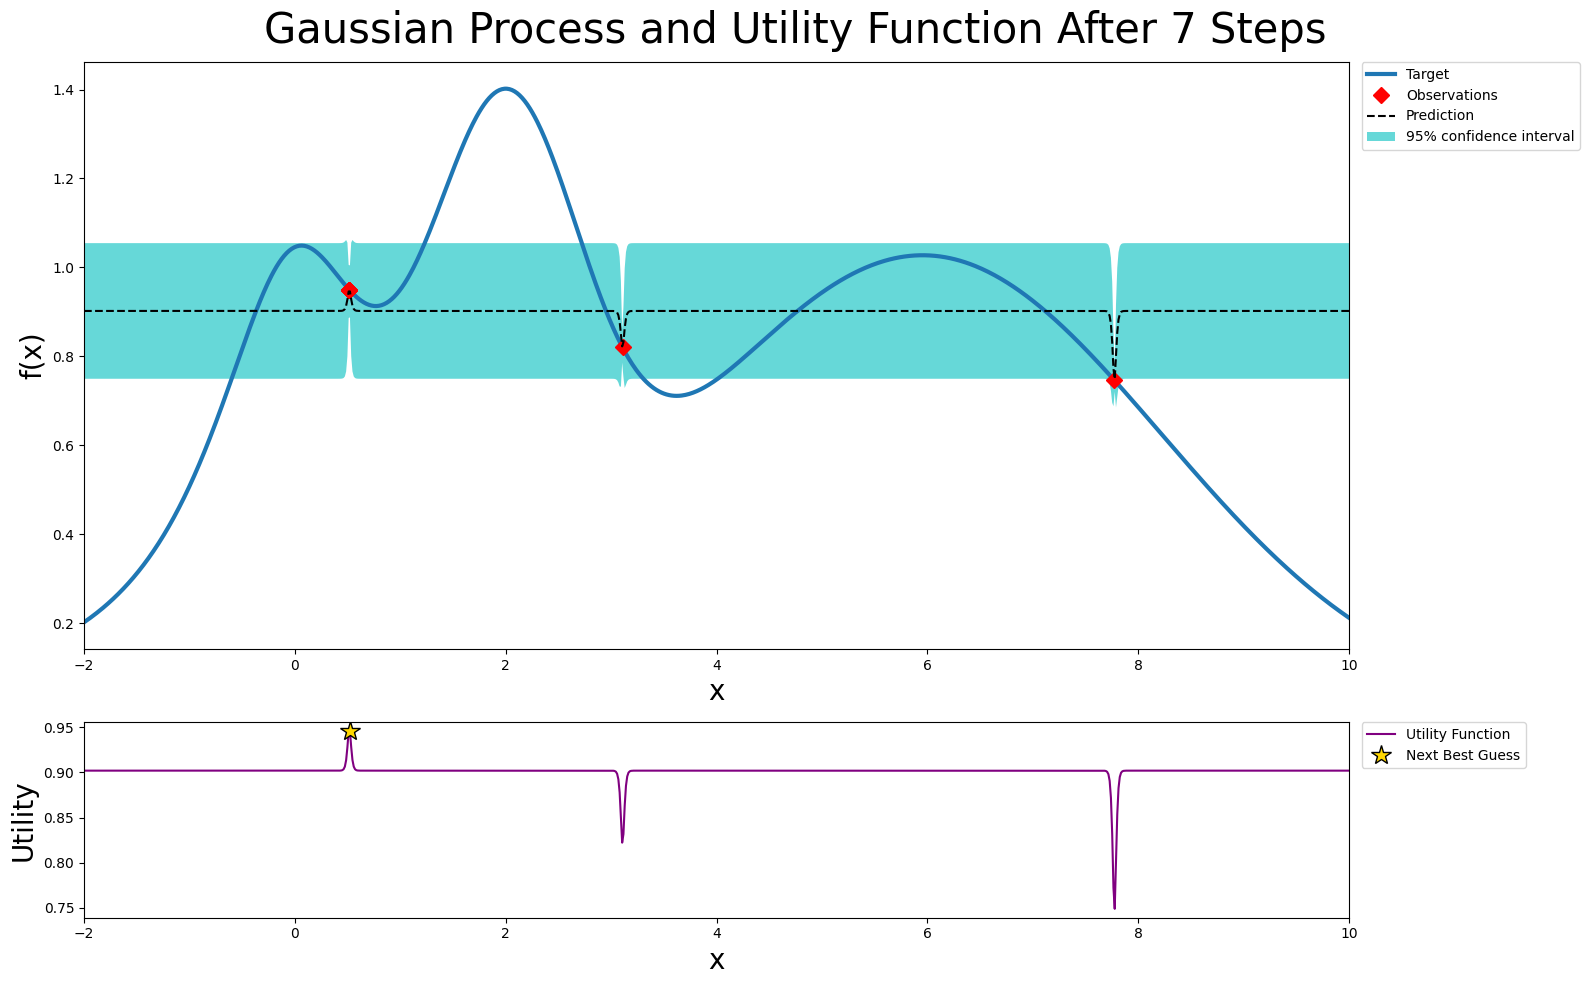


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [19]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Zadanie 1

In [5]:
def run_optimizer(acq_func, name, init_points=2, n_iter=5, random_state=27, show_plot=True):
    optimizer = BayesianOptimization(
        f=target_function,
        pbounds={"x": (-2, 10)},
        acquisition_function=acq_func,
        random_state=random_state,
        verbose=0,
    )

    optimizer.maximize(init_points=init_points, n_iter=n_iter)

    print(f"\n{name}")
    print(f"Best target value found: {optimizer.max['target']:.4f}")
    print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

    if show_plot:
        plot_gp(optimizer, x, y)

    return optimizer


UCB with kappa = 0.1
Best target value found: 1.0490
Best input value found: x = 0.0642


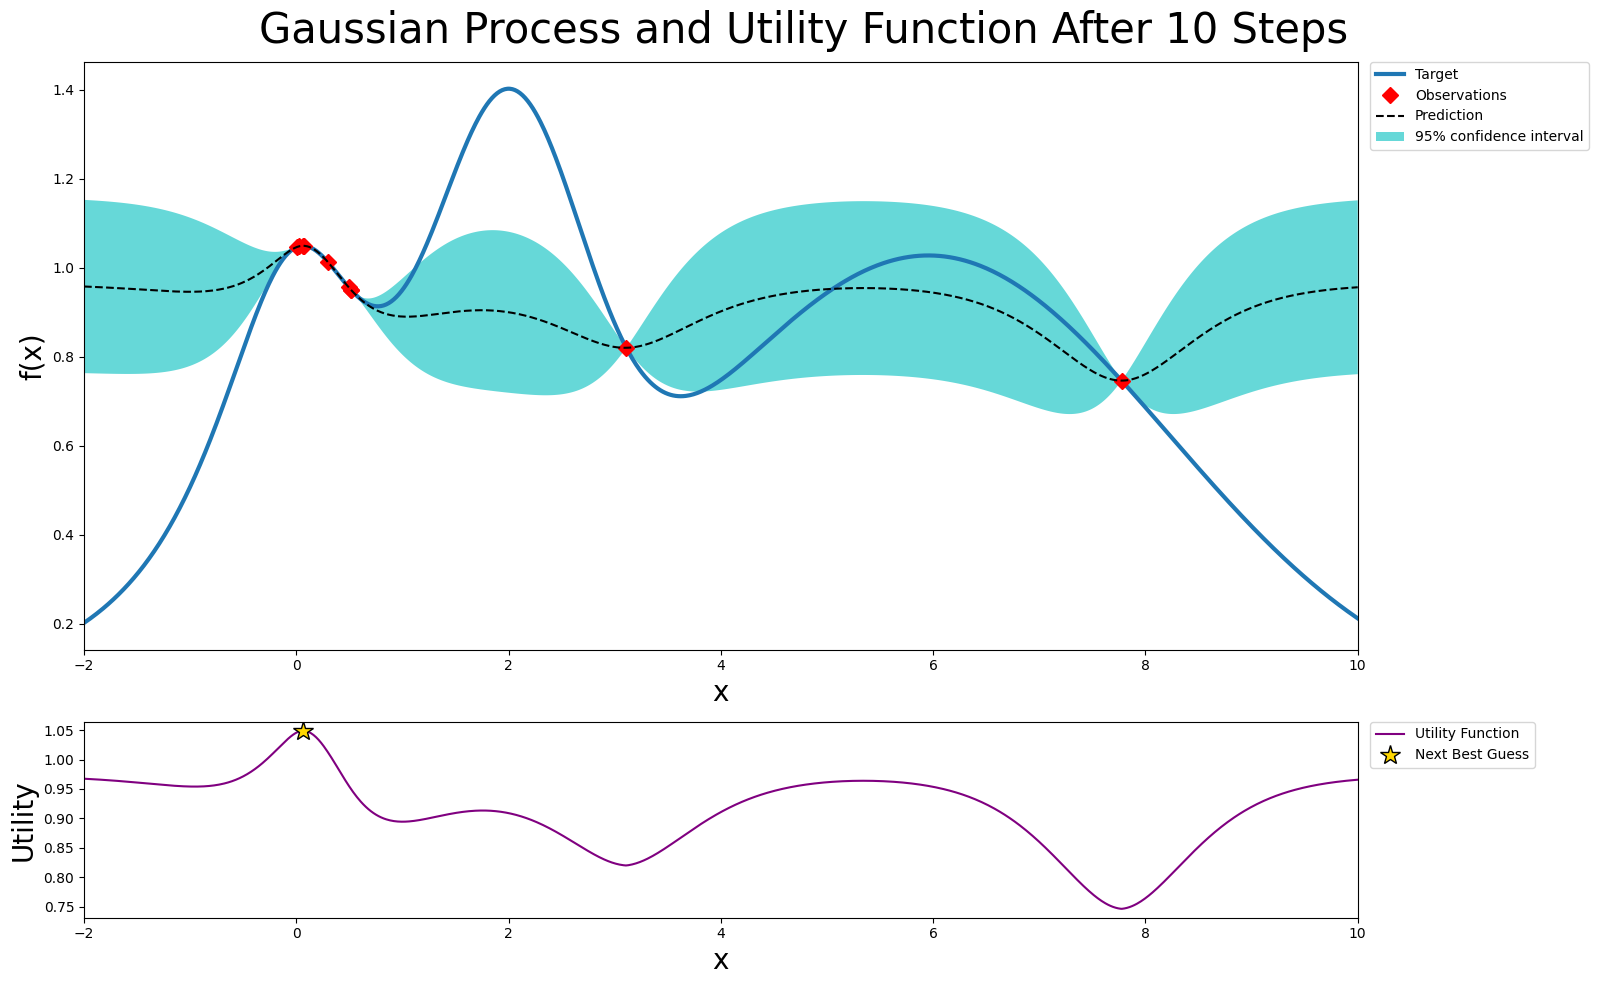


UCB with kappa = 2.5
Best target value found: 1.3701
Best input value found: x = 1.8064


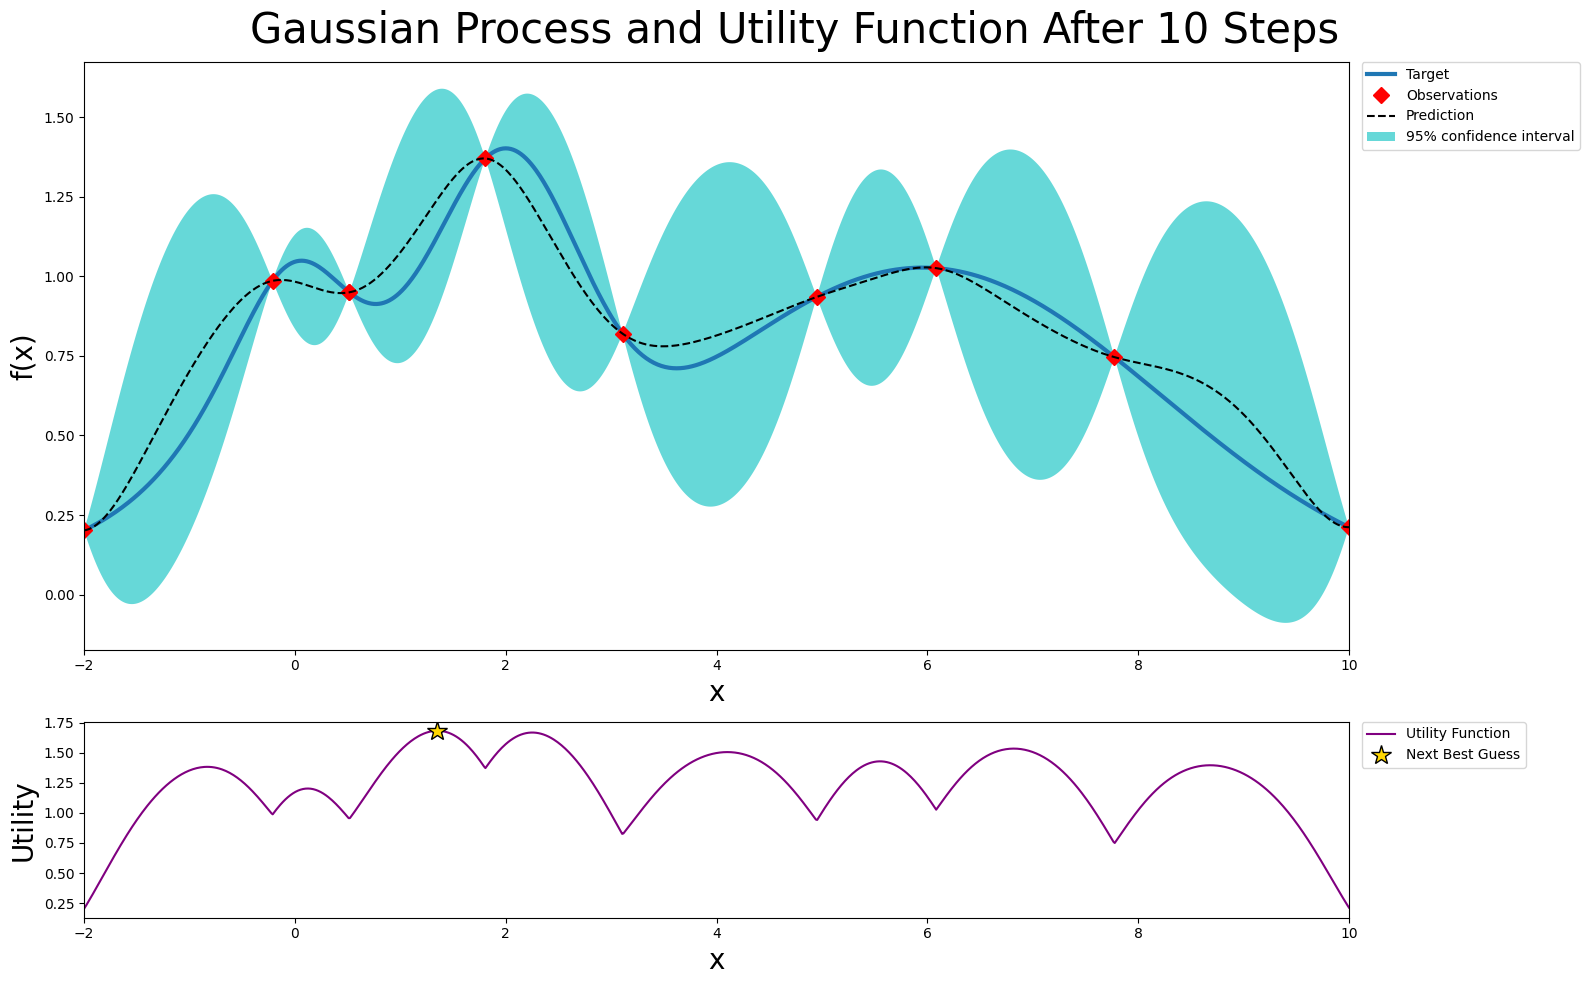


UCB with kappa = 5.0
Best target value found: 1.0098
Best input value found: x = 5.5298


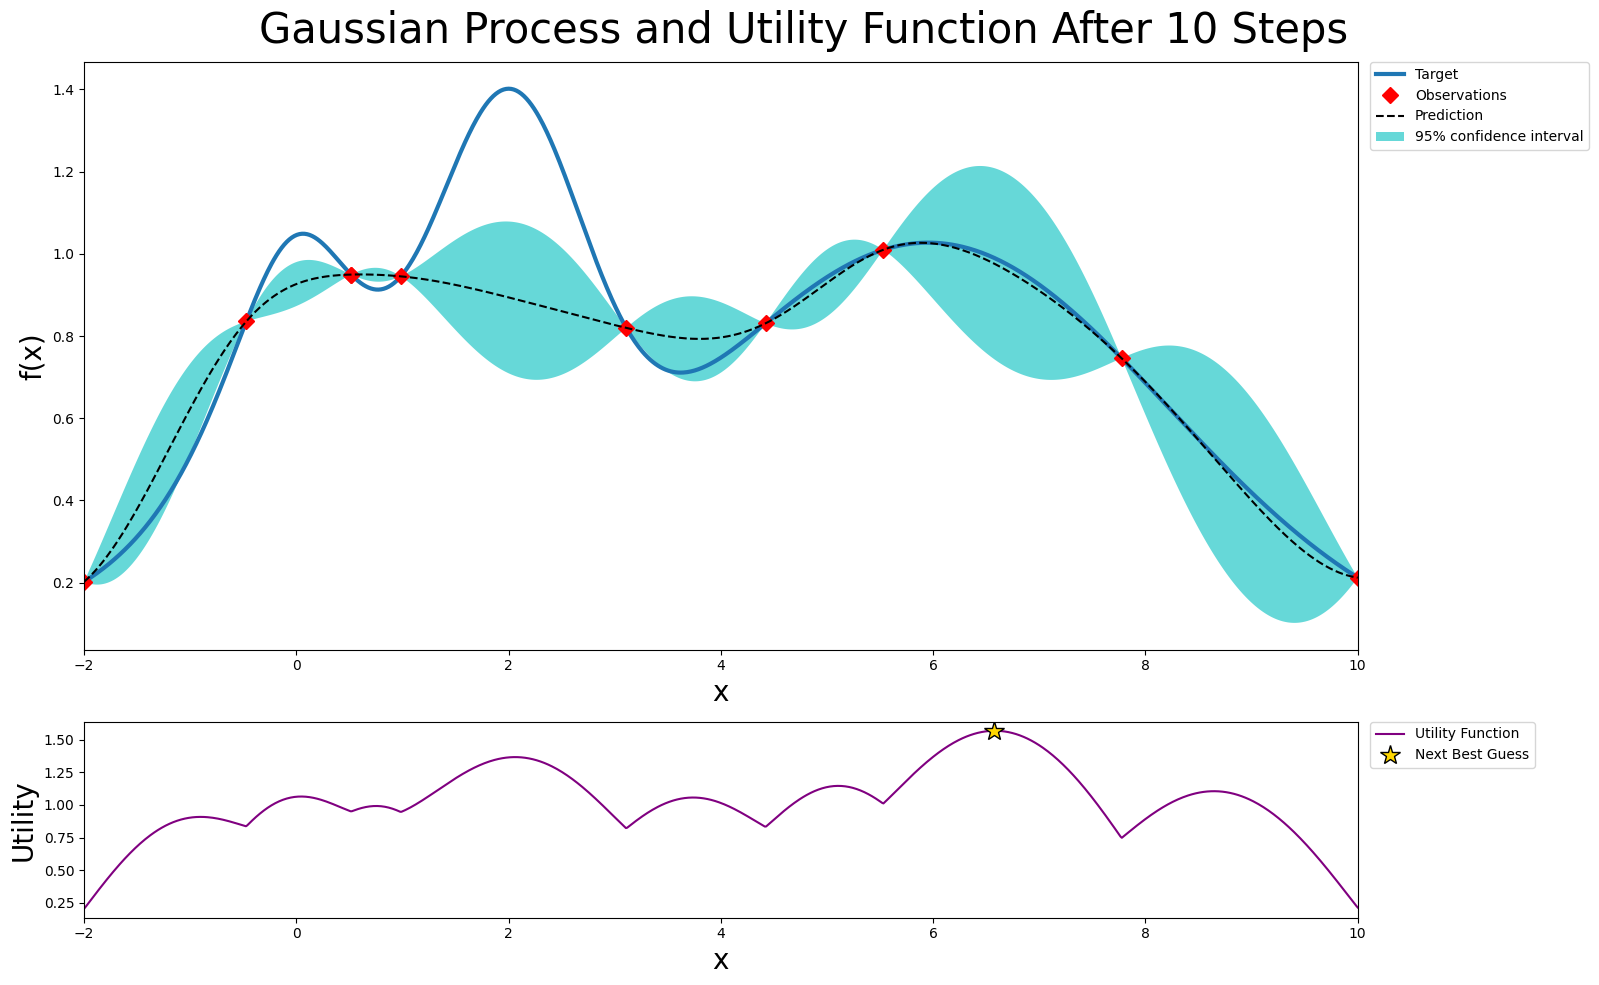

In [11]:
ucb_kappas = [0.1, 2.5, 5.0]
ucb_results = {}

for kappa in ucb_kappas:
    acq_func = acquisition.UpperConfidenceBound(kappa=kappa)
    ucb_results[kappa] = run_optimizer(
        acq_func,
        name=f"UCB with kappa = {kappa}",
        init_points=2,
        n_iter=8,
        random_state=27,
        show_plot=True,
    )

### Exercise 1 — UCB dla różnych wartości kappa

Otrzymane wyniki:

| kappa | Charakter strategii | Najlepsza wartość | Najlepsze x |
|---:|---|---:|---:|
| 0.1 | głównie eksploatacja | 1.0490 | 0.0642 |
| 2.5 | balans eksploracji i eksploatacji | 1.3701 | 1.8064 |
| 5.0 | głównie eksploracja | 1.0098 | 5.5298 |

Funkcja UCB ma postać:

`UCB(x) = mu(x) + kappa * sigma(x)`

gdzie `mu(x)` oznacza przewidywaną wartość funkcji, a `sigma(x)` oznacza niepewność modelu w punkcie `x`. Parametr `kappa` decyduje o tym, jak mocno algorytm premiuje niepewność.

Dla `kappa = 0.1` algorytm zachowuje się głównie eksploatacyjnie. Oznacza to, że wybiera punkty tam, gdzie model przewiduje wysoką wartość funkcji, ale prawie nie uwzględnia niepewności. W tym przypadku najlepszy punkt to `x = 0.0642`, a wartość funkcji wyniosła `1.0490`. Wynik jest lepszy niż w podstawowym porównaniu UCB / PI / Greedy, ale nadal nie trafia w globalne maksimum w okolicy `x ≈ 2`.

Dla `kappa = 2.5` uzyskano zdecydowanie najlepszy wynik: `1.3701` dla `x = 1.8064`. Ten punkt znajduje się blisko głównego maksimum funkcji. Oznacza to, że wartość `kappa = 2.5` dobrze zrównoważyła eksploatację i eksplorację. Algorytm nie ograniczył się tylko do lokalnego maksimum blisko zera, ale zbadał też bardziej obiecujący obszar.

Dla `kappa = 5.0` algorytm był bardzo eksploracyjny. Najlepszy punkt to `x = 5.5298`, a wartość funkcji wyniosła `1.0098`. Wynik ten pokazuje, że zbyt duża eksploracja może odciągnąć algorytm od najlepszego obszaru. Model badał region bardziej niepewny, ale niekoniecznie prowadzący do najwyższej wartości funkcji.

Wniosek: najlepszy wynik dała wartość pośrednia `kappa = 2.5`. Zbyt małe `kappa` powoduje zbyt silną eksploatację, a zbyt duże `kappa` prowadzi do nadmiernej eksploracji. W tym przykładzie najlepiej sprawdził się kompromis między tymi dwoma zachowaniami.

Zadanie 2

In [7]:
class ChaoticAcquisition(acquisition.AcquisitionFunction):
    """
    Funkcja akwizycji, która ignoruje przewidywaną średnią
    i wybiera punkty wyłącznie na podstawie niepewności modelu.
    """

    def __init__(self, random_state=None):
        super().__init__(random_state=random_state)

    def base_acq(self, mean, std):
        return std


UCB, kappa=2.5
Best target value found: 0.9857
Best input value found: x = -0.2118


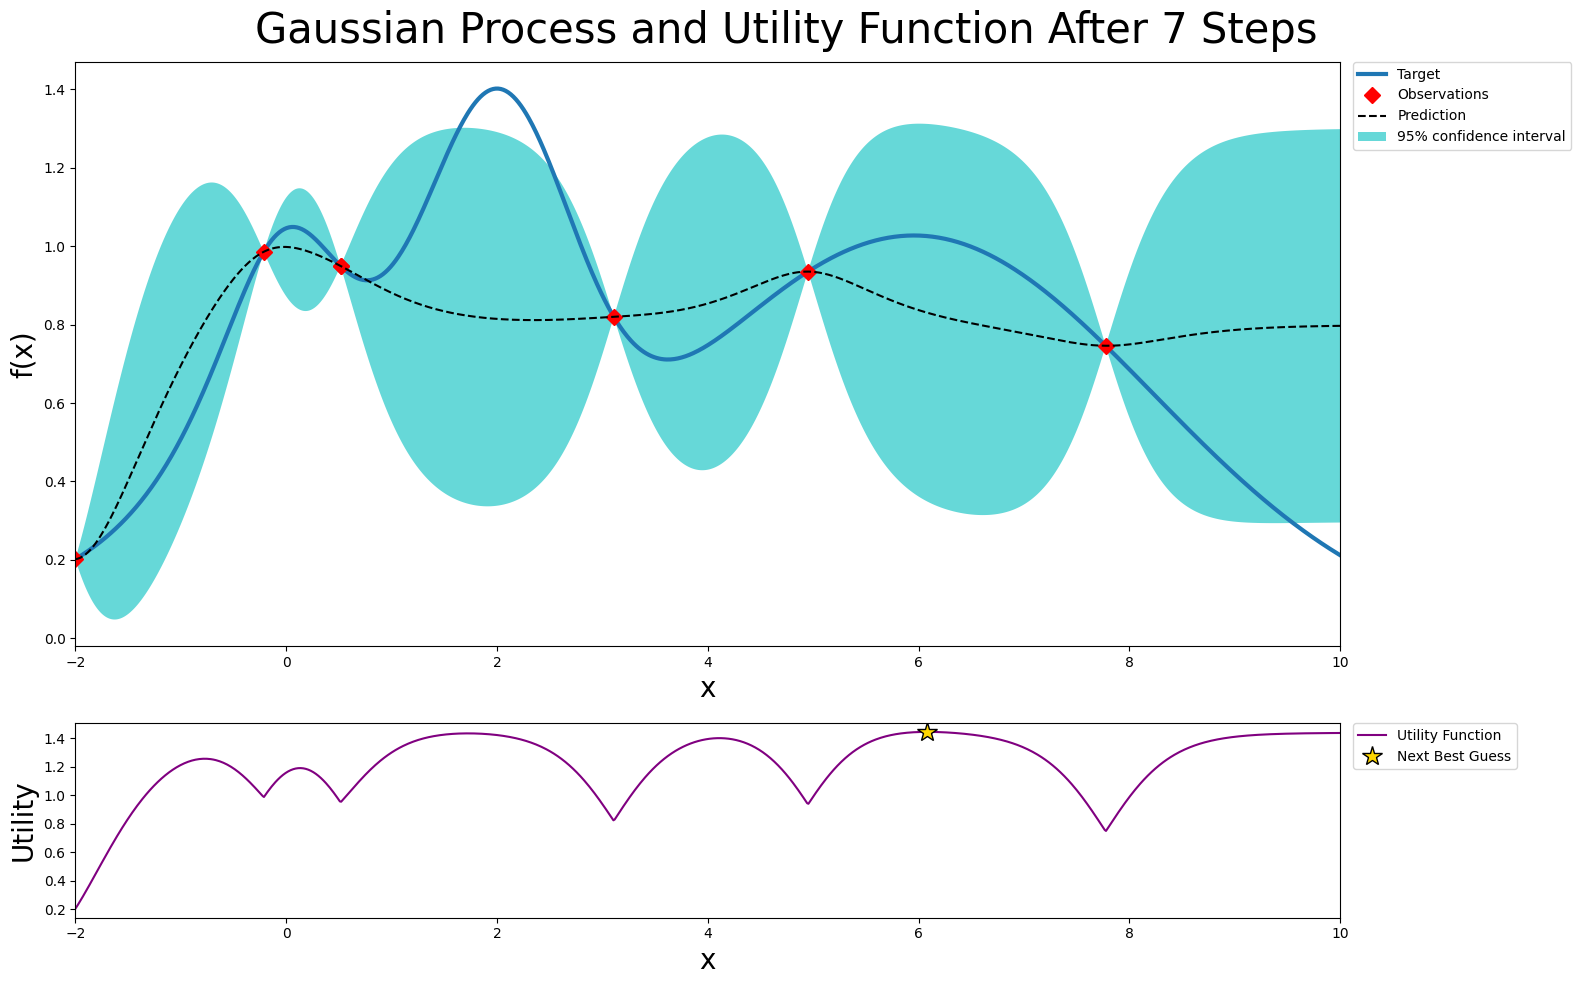


PI, xi=1e-4
Best target value found: 0.9594
Best input value found: x = 0.4802


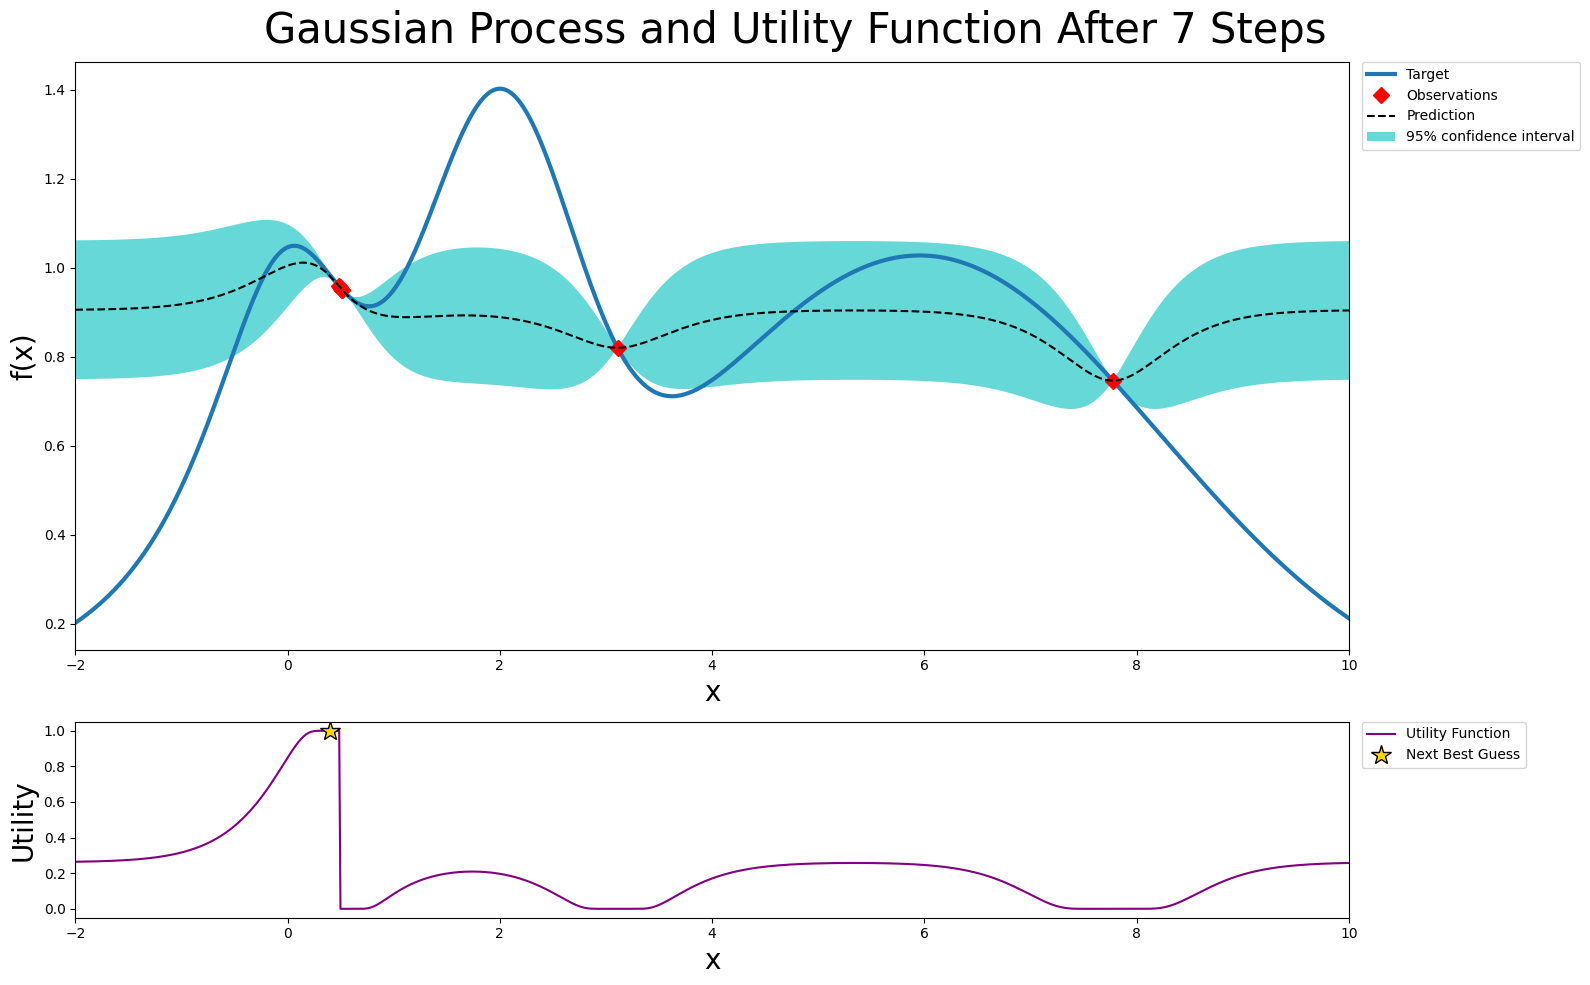


Chaotic, std only
Best target value found: 0.9990
Best input value found: x = 5.4116


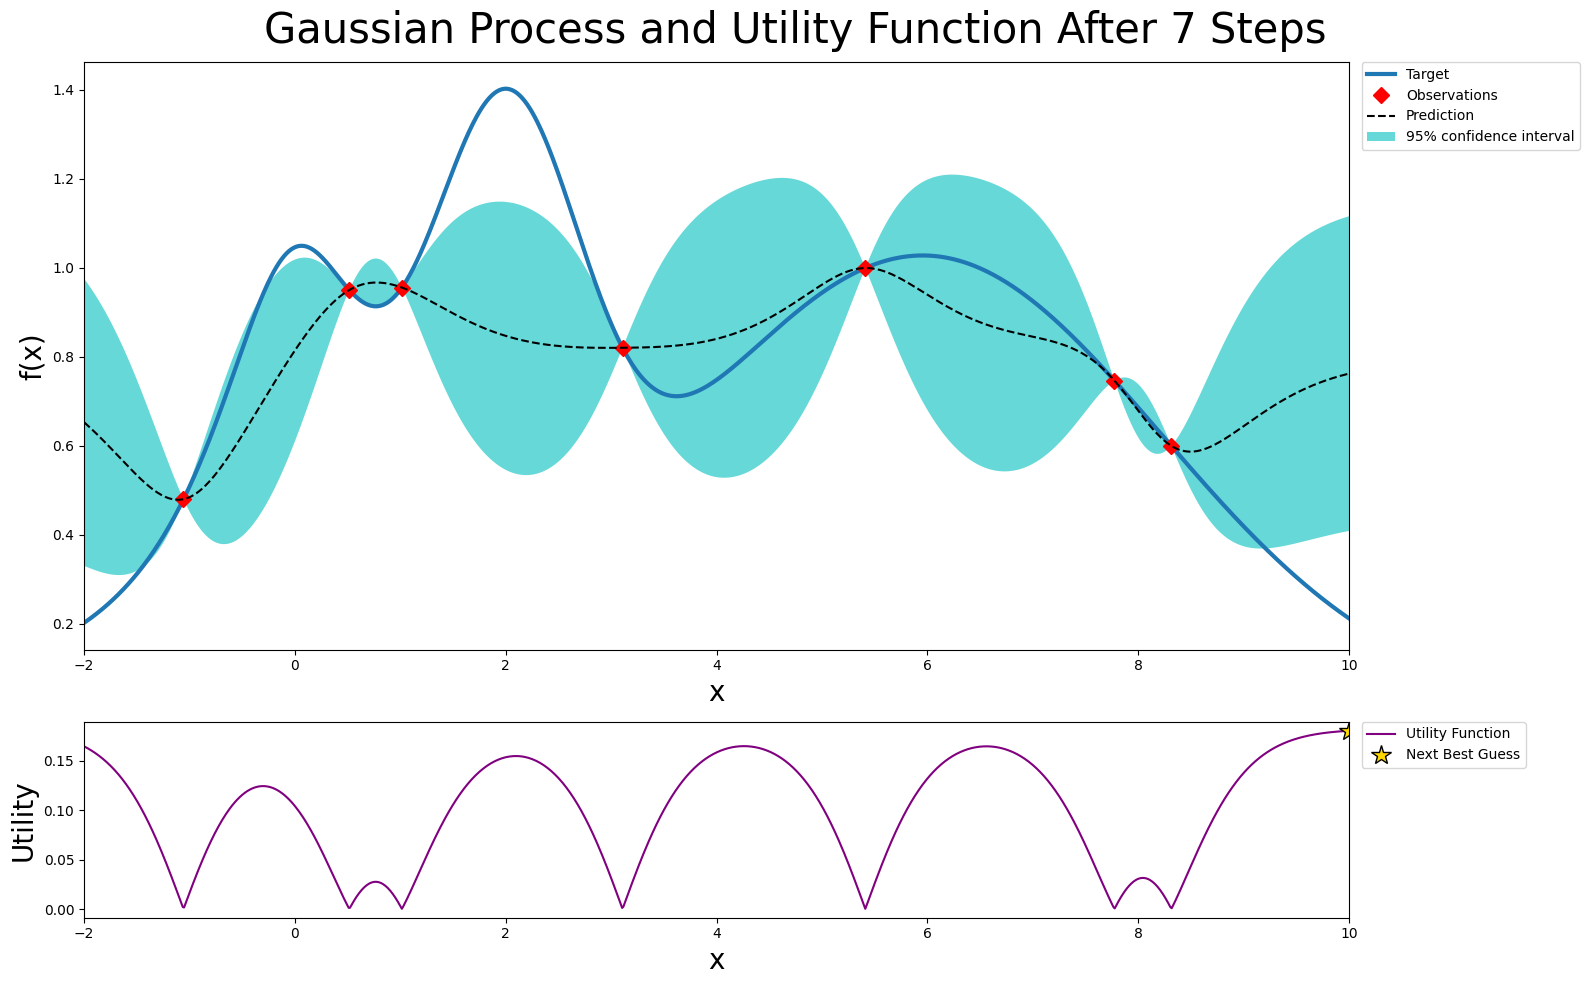

In [8]:
comparison_acq = {
    "UCB, kappa=2.5": acquisition.UpperConfidenceBound(kappa=2.5),
    "PI, xi=1e-4": acquisition.ProbabilityOfImprovement(xi=1e-4),
    "Chaotic, std only": ChaoticAcquisition(),
}

chaotic_comparison_results = {}

for name, acq_func in comparison_acq.items():
    chaotic_comparison_results[name] = run_optimizer(
        acq_func,
        name=name,
        init_points=2,
        n_iter=5,
        random_state=27,
        show_plot=True,
    )

In [9]:
print("\nSummary: UCB vs PI vs Chaotic")

for name, optimizer in chaotic_comparison_results.items():
    print(
        f"{name}: "
        f"best value={optimizer.max['target']:.4f}, "
        f"x={optimizer.max['params']['x']:.4f}"
    )


Summary: UCB vs PI vs Chaotic
UCB, kappa=2.5: best value=0.9857, x=-0.2118
PI, xi=1e-4: best value=0.9594, x=0.4802
Chaotic, std only: best value=0.9990, x=5.4116


### Exercise 2 — Chaotic Acquisition Function

Otrzymane wyniki:

| Metoda | Najlepsza wartość | Najlepsze x |
|---|---:|---:|
| UCB, kappa=2.5 | 0.9857 | -0.2118 |
| PI, xi=1e-4 | 0.9594 | 0.4802 |
| Chaotic, std only | 0.9990 | 5.4116 |

Funkcja `ChaoticAcquisition` wybiera punkty wyłącznie na podstawie niepewności modelu, czyli wartości `sigma(x)`. Ignoruje przewidywaną średnią `mu(x)`. Oznacza to, że jest to strategia czystej eksploracji.

W tym eksperymencie metoda Chaotic osiągnęła najlepszy wynik spośród trzech porównywanych metod: `0.9990` dla `x = 5.4116`. Jest to wynik nieco lepszy niż UCB oraz PI. Nie oznacza to jednak, że Chaotic jest ogólnie najlepszą metodą optymalizacji. W tym przypadku zadziałało to dlatego, że eksploracja skierowała algorytm w okolice innego piku funkcji, znajdującego się w pobliżu `x ≈ 6`.

UCB osiągnęła wynik `0.9857` dla `x = -0.2118`, a PI wynik `0.9594` dla `x = 0.4802`. Obie metody pozostały bliżej lokalnego maksimum w okolicy zera. PI była najbardziej zachowawcza, natomiast UCB uwzględniała niepewność, ale w tym konkretnym uruchomieniu nie zbadała wystarczająco skutecznie obszaru przy `x ≈ 2` ani `x ≈ 6`.

Metoda Chaotic dobrze pokazuje wartość eksploracji. Dzięki ignorowaniu średniej modelu wybierała punkty słabo poznane, co pozwoliło jej znaleźć lepszy obszar niż PI i UCB w tym konkretnym porównaniu.

Jednocześnie jej ograniczenie jest jasne: skoro ignoruje przewidywaną wartość funkcji, może marnować ewaluacje na obszary, które są niepewne, ale mało obiecujące. Dlatego czysta eksploracja może czasem przypadkowo znaleźć dobry punkt, ale zwykle nie jest tak efektywna jak metody równoważące eksplorację i eksploatację.

Wniosek: w tym eksperymencie Chaotic uzyskała najlepszy wynik, ponieważ mocna eksploracja doprowadziła ją do innego lokalnego maksimum. Nie jest to jednak dowód, że strategia oparta wyłącznie na niepewności jest najlepsza. Pokazuje raczej, że eksploracja jest ważna, szczególnie gdy liczba początkowych obserwacji jest mała.

Zadanie 3

In [13]:
from scipy.stats import norm
class ExpectedImprovement(acquisition.AcquisitionFunction):
    """
    Własna implementacja Expected Improvement.

    EI mierzy oczekiwaną wielkość poprawy względem najlepszego
    dotychczas zaobserwowanego wyniku y_max.
    """

    def __init__(self, xi=0.0, random_state=None):
        super().__init__(random_state=random_state)
        self.xi = xi
        self.y_max = None

    def base_acq(self, mean, std):
        if self.y_max is None:
            raise ValueError(
                "y_max is not set. It should be updated inside suggest()."
            )

        mean = np.asarray(mean)
        std = np.asarray(std)

        improvement = mean - self.y_max - self.xi

        # Zabezpieczenie numeryczne: gdy std == 0, unikamy dzielenia przez zero.
        ei = np.zeros_like(mean, dtype=float)
        mask = std > 0

        z = np.zeros_like(mean, dtype=float)
        z[mask] = improvement[mask] / std[mask]

        ei[mask] = (
            improvement[mask] * norm.cdf(z[mask])
            + std[mask] * norm.pdf(z[mask])
        )

        # Granica EI dla std == 0
        ei[~mask] = np.maximum(improvement[~mask], 0.0)

        return ei

    def suggest(
        self,
        gp,
        target_space,
        n_random=10_000,
        n_smart=10,
        fit_gp=True,
        random_state=None,
    ):
        # W bayes_opt aktualne maksimum jest przechowywane w target_space.
        # Używamy _target_max(), podobnie jak ProbabilityOfImprovement.
        try:
            self.y_max = target_space._target_max()
        except AttributeError:
            self.y_max = np.max(target_space.target)

        return super().suggest(
            gp=gp,
            target_space=target_space,
            n_random=n_random,
            n_smart=n_smart,
            fit_gp=fit_gp,
            random_state=random_state,
        )

    def get_acquisition_params(self):
        return {"xi": self.xi, "y_max": self.y_max}

    def set_acquisition_params(self, params):
        self.xi = params["xi"]
        self.y_max = params.get("y_max", None)


UCB, kappa=2.5
Best target value found: 0.9857
Best input value found: x = -0.2118


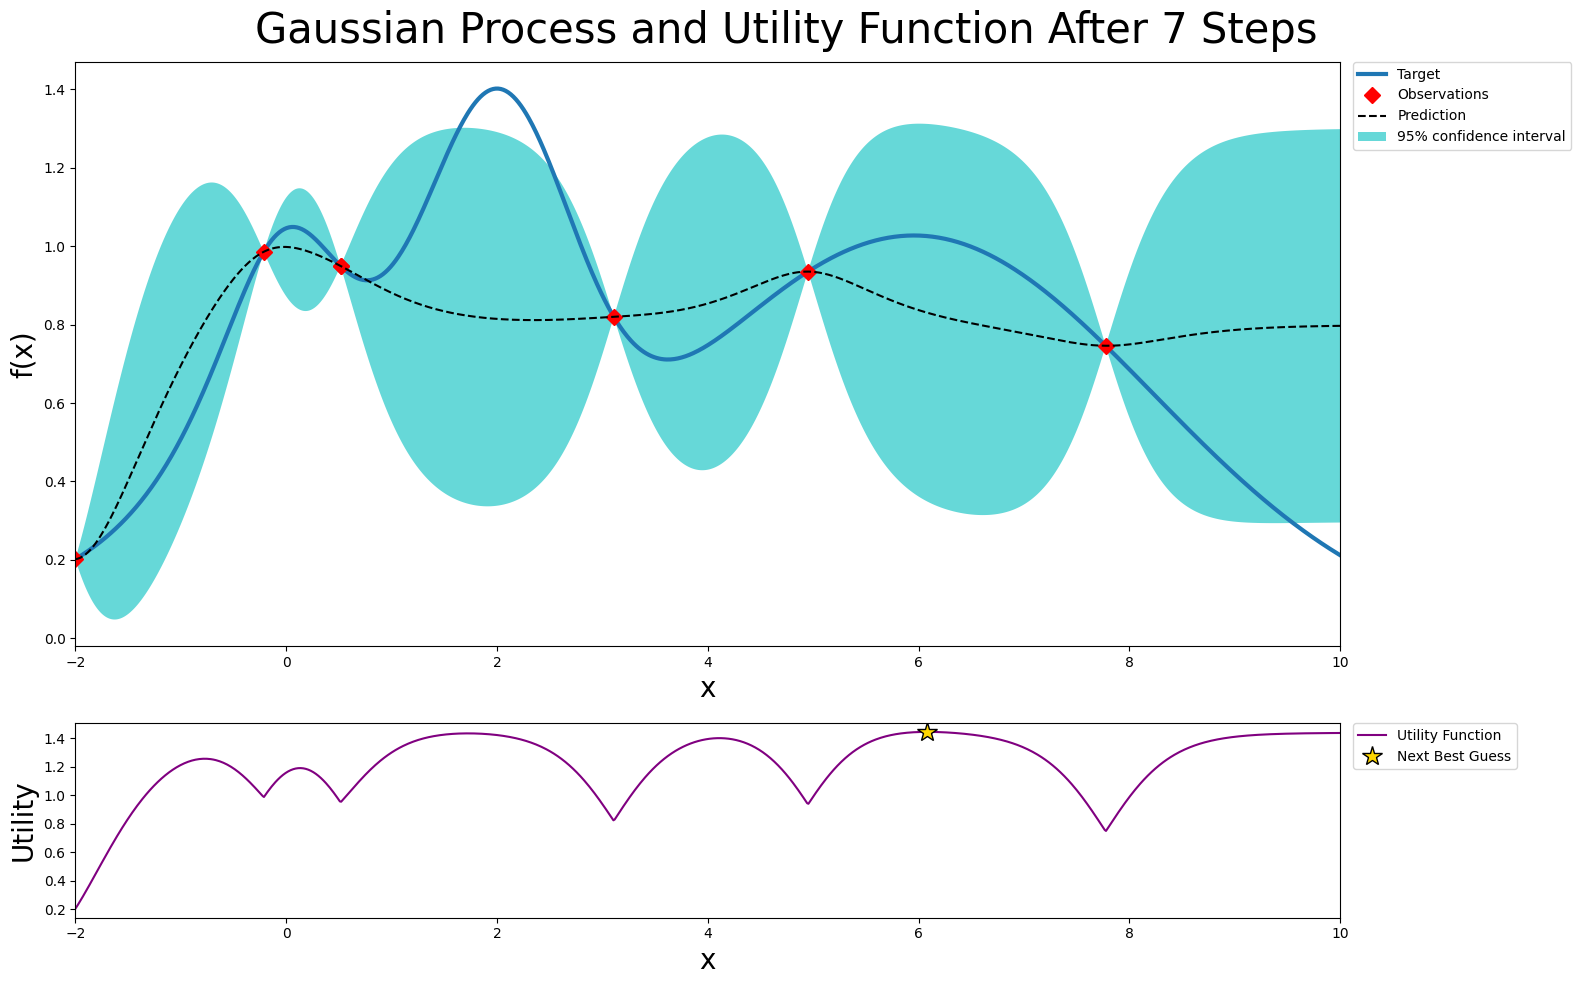


PI, xi=1e-4
Best target value found: 0.9594
Best input value found: x = 0.4802


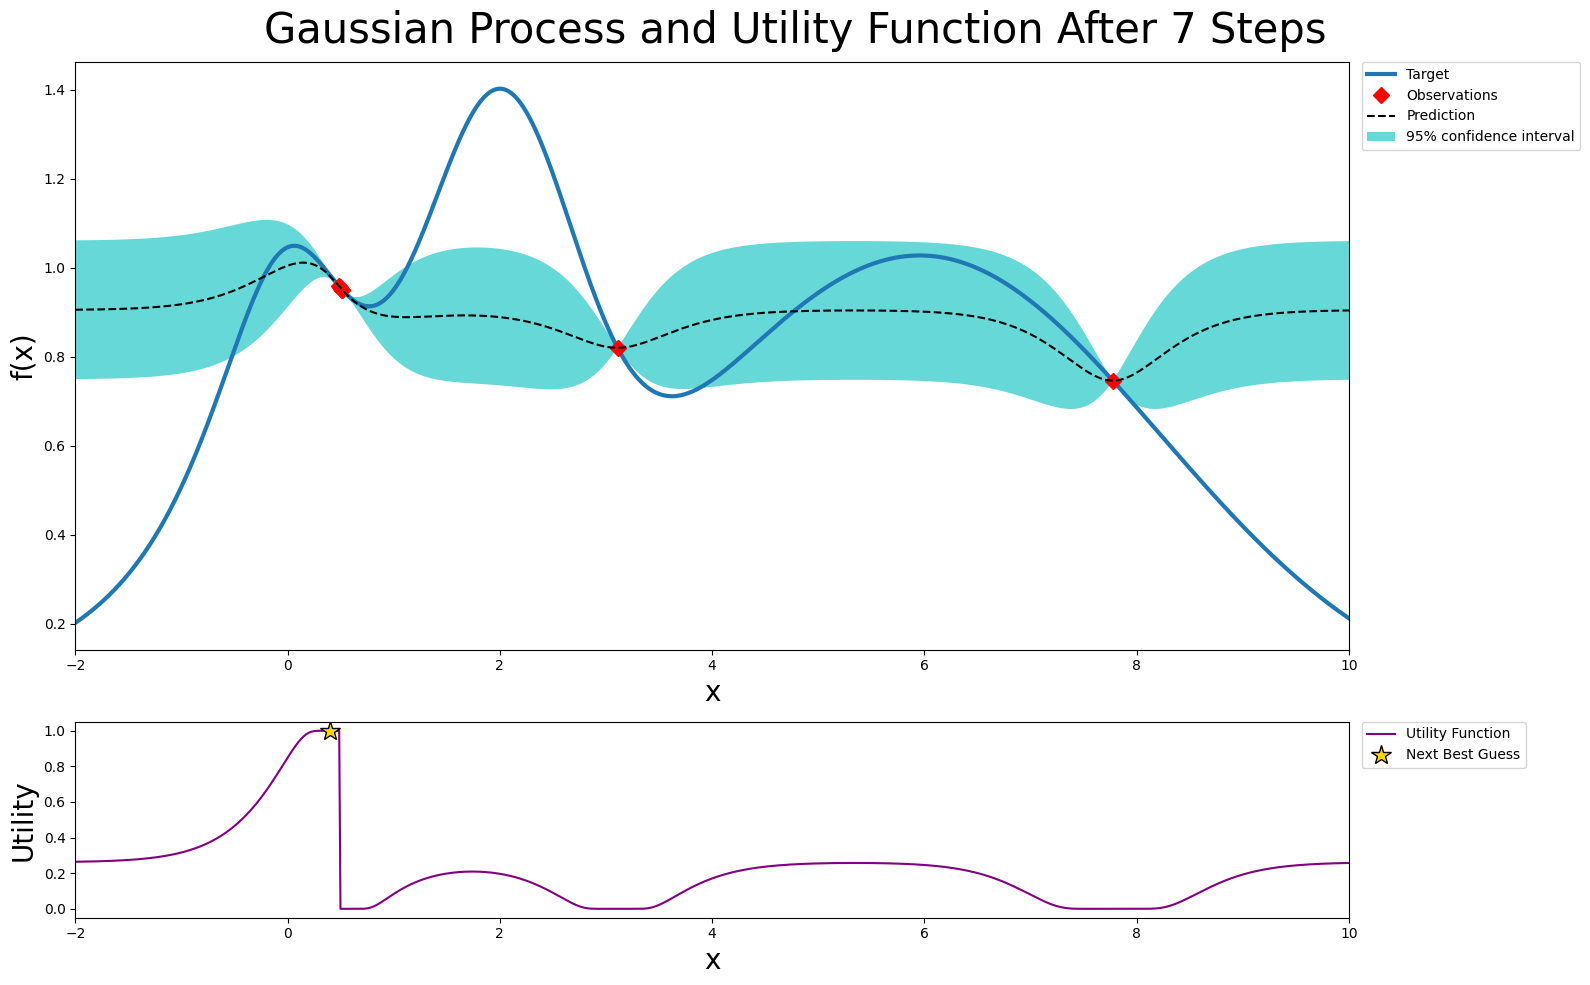


EI, xi=1e-4
Best target value found: 1.0486
Best input value found: x = 0.0424


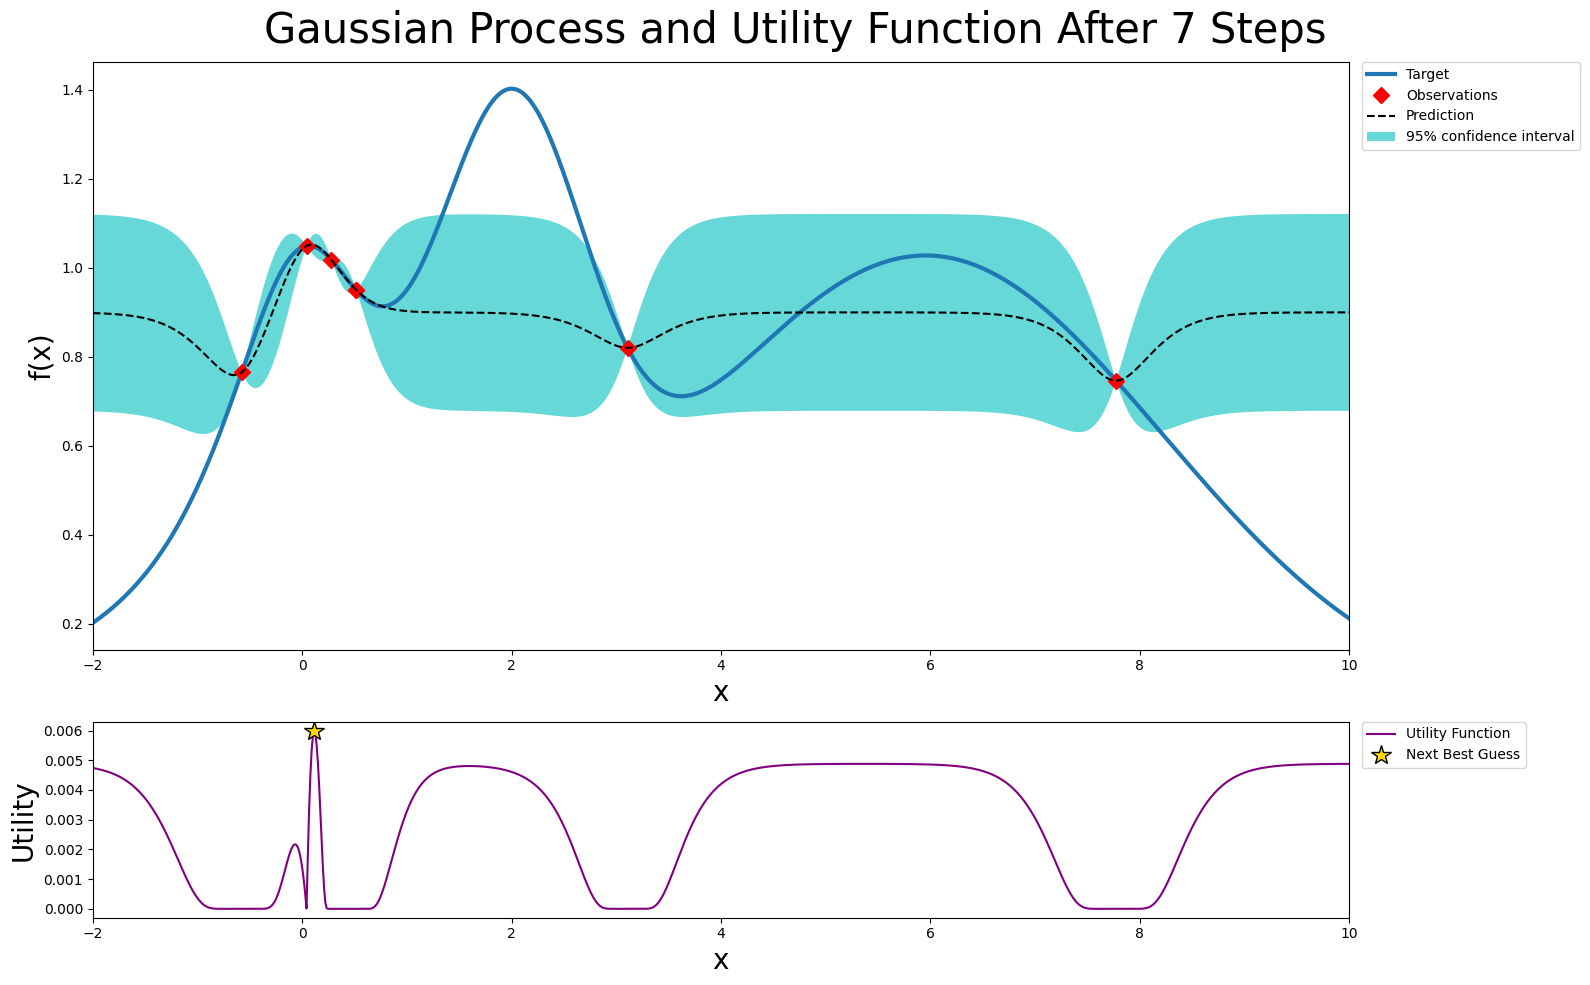


Greedy
Best target value found: 0.9495
Best input value found: x = 0.5166


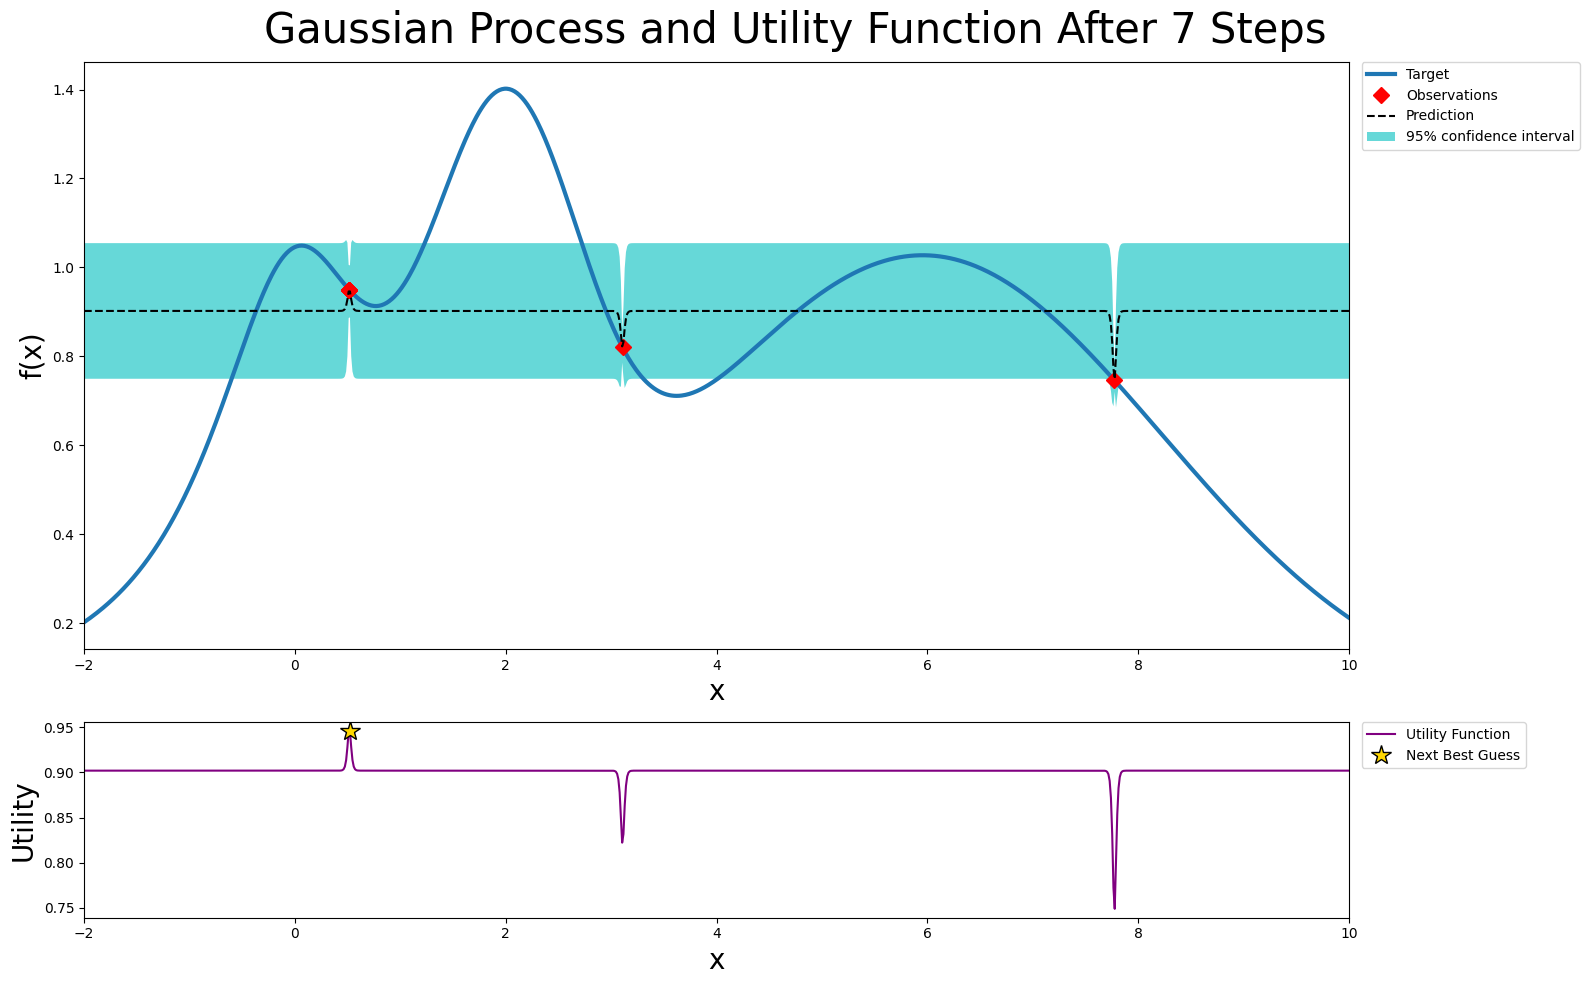

In [20]:
comparison_acq_ei = {
    "UCB, kappa=2.5": acquisition.UpperConfidenceBound(kappa=2.5),
    "PI, xi=1e-4": acquisition.ProbabilityOfImprovement(xi=1e-4),
    "EI, xi=1e-4": ExpectedImprovement(xi=1e-4),
    "Greedy": GreedyAcquisition(),
}

ei_comparison_results = {}

for name, acq_func in comparison_acq_ei.items():
    ei_comparison_results[name] = run_optimizer(
        acq_func,
        name=name,
        init_points=2,
        n_iter=5,
        random_state=27,
        show_plot=True,
    )

### Exercise 3 — Expected Improvement

Otrzymane wyniki:

| Metoda | Najlepsza wartość | Najlepsze x |
|---|---:|---:|
| UCB, kappa=2.5 | 0.9857 | -0.2118 |
| PI, xi=1e-4 | 0.9594 | 0.4802 |
| EI, xi=1e-4 | 1.0486 | 0.0424 |
| Greedy | 0.9495 | 0.5166 |

Expected Improvement osiągnęło najlepszy wynik spośród metod porównywanych w tym ćwiczeniu: `1.0486` dla `x = 0.0424`. Jest to lepszy wynik niż UCB, PI i Greedy, ale nadal nie jest to globalne maksimum funkcji w okolicy `x ≈ 2`.

EI działa inaczej niż PI. PI sprawdza głównie prawdopodobieństwo tego, że nowy punkt poprawi aktualnie najlepszy wynik. EI bierze pod uwagę nie tylko prawdopodobieństwo poprawy, ale również jej oczekiwaną wielkość. Dzięki temu EI może być mniej zachowawcze niż PI.

Wynik PI, czyli `0.9594` dla `x = 0.4802`, pokazuje, że metoda ta skupiła się na lokalnie bezpiecznym obszarze. Greedy osiągnęła jeszcze słabszy wynik: `0.9495` dla `x = 0.5166`, ponieważ całkowicie ignorowała niepewność modelu.

UCB osiągnęła `0.9857` dla `x = -0.2118`. W tym konkretnym porównaniu była słabsza od EI, mimo że również uwzględnia niepewność. Może to wynikać z tego, że przy danej liczbie iteracji i konkretnych punktach początkowych UCB nie skierowała wyszukiwania w odpowiednio obiecujący region.

EI uzyskało wynik powyżej `1.0`, co oznacza, że znalazło punkt lepszy niż pozostałe standardowe metody w tym ćwiczeniu. Nadal jednak skupiło się na maksimum w pobliżu zera, a nie na najwyższym piku w okolicy `x ≈ 2`.

Wniosek: w tym eksperymencie EI było najlepsze spośród porównywanych metod, ponieważ lepiej wykorzystało informację o potencjalnej poprawie. Wynik pokazuje, że EI jest silną i praktyczną funkcją akwizycji, ale przy małym budżecie ewaluacji nadal może nie znaleźć globalnego maksimum.

### Exercise 4 — Pytania teoretyczne

#### 1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?

Bayesian Optimization jest szczególnie użyteczna wtedy, gdy każda ewaluacja funkcji celu jest kosztowna, czasochłonna albo trudna do wykonania. Przykładami mogą być trenowanie dużego modelu uczenia maszynowego, uruchomienie złożonej symulacji albo przeprowadzenie eksperymentu laboratoryjnego.

W takich sytuacjach nie chcemy sprawdzać bardzo wielu kombinacji parametrów metodą grid search lub random search, ponieważ każda próba może zajmować dużo czasu albo wymagać dużych zasobów.

Bayesian Optimization rozwiązuje ten problem przez budowanie modelu zastępczego, najczęściej Gaussian Process. Model ten przybliża nieznaną funkcję celu na podstawie dotychczasowych obserwacji. Dodatkowo dla każdego punktu podaje dwie ważne informacje:

- przewidywaną wartość funkcji, czyli `mu(x)`,
- niepewność tej predykcji, czyli `sigma(x)`.

Dzięki temu algorytm może wybierać kolejne punkty w bardziej inteligentny sposób. Nie musi poznawać całej funkcji bardzo dokładnie. Zamiast tego skupia się na szybkim znalezieniu możliwie dobrego maksimum lub minimum przy ograniczonej liczbie ewaluacji.

W tym sensie Bayesian Optimization jest efektywna, ponieważ przenosi większość pracy na tani obliczeniowo model zastępczy i drogą funkcję celu wywołuje tylko dla starannie wybranych punktów.

---

#### 2. Compare and contrast the different acquisition functions discussed in this tutorial.

W eksperymentach porównano kilka funkcji akwizycji: Greedy, UCB, PI, Chaotic oraz EI.

**Greedy**

Greedy używa wyłącznie przewidywanej średniej modelu, czyli `mu(x)`. Ignoruje niepewność `sigma(x)`, dlatego jest strategią czystej eksploatacji.

W wynikach Greedy uzyskała:

- najlepsza wartość: `0.9495`,
- najlepsze `x`: `0.5166`.

Był to najsłabszy wynik w porównaniu z UCB, PI i EI. Pokazuje to, że sama eksploatacja może zbyt szybko skierować algorytm do lokalnie dobrego obszaru, bez sprawdzenia innych potencjalnie lepszych regionów.

**UCB**

UCB, czyli Upper Confidence Bound, łączy przewidywaną średnią i niepewność modelu. Można ją zapisać tekstowo jako:

`UCB(x) = mu(x) + kappa * sigma(x)`

Parametr `kappa` kontroluje, jak silnie algorytm premiuje niepewność. Małe `kappa` oznacza większą eksploatację, a duże `kappa` oznacza większą eksplorację.

W podstawowym porównaniu UCB uzyskała:

- najlepsza wartość: `0.9857`,
- najlepsze `x`: `-0.2118`.

Jednak w Exercise 1 wyniki mocno zależały od wartości `kappa`:

| kappa | Najlepsza wartość | Najlepsze x | Interpretacja |
|---:|---:|---:|---|
| 0.1 | 1.0490 | 0.0642 | głównie eksploatacja |
| 2.5 | 1.3701 | 1.8064 | dobry balans |
| 5.0 | 1.0098 | 5.5298 | głównie eksploracja |

Najlepszy wynik w całych eksperymentach dało UCB z `kappa = 2.5`. Punkt `x = 1.8064` znajduje się blisko głównego maksimum funkcji, co pokazuje, że dobrze dobrany kompromis między eksploracją i eksploatacją może być bardzo skuteczny.

**PI**

PI, czyli Probability of Improvement, wybiera punkty, które mają największe prawdopodobieństwo poprawy względem aktualnie najlepszego wyniku.

Wynik PI:

- najlepsza wartość: `0.9594`,
- najlepsze `x`: `0.4802`.

PI była lepsza niż Greedy, ale słabsza niż UCB i EI. Jej ograniczeniem jest to, że bierze pod uwagę głównie prawdopodobieństwo poprawy, ale nie rozróżnia dobrze małej i dużej poprawy. Punkt z dużą szansą minimalnej poprawy może zostać oceniony lepiej niż punkt z mniejszą szansą, ale większym potencjalnym zyskiem.

**EI**

EI, czyli Expected Improvement, mierzy oczekiwaną wielkość poprawy względem najlepszego dotychczasowego wyniku. Jest więc bardziej informacyjna niż PI, ponieważ uwzględnia zarówno prawdopodobieństwo poprawy, jak i jej potencjalną skalę.

W Exercise 3 EI uzyskała:

- najlepsza wartość: `1.0486`,
- najlepsze `x`: `0.0424`.

Był to najlepszy wynik spośród UCB, PI, EI i Greedy w tym konkretnym porównaniu z Exercise 3. EI znalazła punkt lepszy niż metody bardziej zachowawcze, ale nadal nie trafiła w globalne maksimum w okolicy `x ≈ 2`.

**Chaotic / std only**

Chaotic Acquisition Function wybiera punkty wyłącznie na podstawie niepewności modelu, czyli `sigma(x)`. Ignoruje przewidywaną średnią `mu(x)`. Jest to strategia czystej eksploracji.

W Exercise 2 uzyskała:

- najlepsza wartość: `0.9990`,
- najlepsze `x`: `5.4116`.

Był to wynik lepszy niż UCB i PI w tym konkretnym porównaniu. Stało się tak dlatego, że metoda mocno eksplorowała przestrzeń i trafiła w okolice innego lokalnego maksimum, blisko `x ≈ 6`.

Nie oznacza to jednak, że Chaotic jest ogólnie najlepszą strategią. Ponieważ ignoruje przewidywaną wartość funkcji, może marnować ewaluacje na obszary bardzo niepewne, ale mało obiecujące.

**Podsumowanie porównania**

Najbardziej stabilne i praktyczne są funkcje, które łączą eksplorację i eksploatację, czyli przede wszystkim UCB oraz EI.

W tych eksperymentach:

- najlepszy pojedynczy wynik dało UCB z `kappa = 2.5`: `1.3701` dla `x = 1.8064`,
- EI była najlepsza w porównaniu z Exercise 3: `1.0486` dla `x = 0.0424`,
- Chaotic pokazała wartość silnej eksploracji, osiągając `0.9990` dla `x = 5.4116`,
- PI i Greedy były bardziej zachowawcze i zatrzymały się bliżej lokalnego maksimum w okolicy `x = 0`.

Wniosek: najlepsze wyniki daje zwykle strategia, która nie jest ani czysto eksploracyjna, ani czysto eksploatacyjna. Potrzebny jest kompromis między badaniem nowych obszarów a wykorzystywaniem miejsc, które model już uważa za obiecujące.

---

#### 3. What are the limitations of Bayesian Optimization?

Bayesian Optimization ma kilka ważnych ograniczeń.

**1. Problemy przy dużej liczbie wymiarów**

Bayesian Optimization działa najlepiej dla małej lub średniej liczby parametrów. Gdy liczba wymiarów rośnie, przestrzeń poszukiwań staje się bardzo duża i trudna do efektywnego przeszukania.

Wysokowymiarowe problemy wymagają większej liczby obserwacji, aby model zastępczy dobrze opisał funkcję celu. W praktyce może to osłabić przewagę Bayesian Optimization nad prostszymi metodami.

**2. Koszt uczenia modelu Gaussian Process**

Gaussian Process jest wygodnym modelem zastępczym, ponieważ daje zarówno predykcję, jak i niepewność. Jednak jego aktualizacja może być kosztowna obliczeniowo, gdy liczba obserwacji rośnie.

W klasycznym BO zwykle liczba ewaluacji jest mała, więc nie jest to duży problem. Jeśli jednak zbierzemy bardzo dużo punktów, standardowy GP może stać się zbyt wolny.

**3. Wrażliwość na dobór modelu i jego założeń**

BO zakłada, że model zastępczy dobrze przybliża funkcję celu. Jeśli funkcja jest bardzo nieregularna, skokowa, silnie zaszumiona albo ma nietypową strukturę, Gaussian Process może ją modelować słabo.

Wtedy funkcja akwizycji opiera się na błędnych predykcjach i może wybierać słabe punkty.

**4. Trudność ze zmiennymi dyskretnymi i kategorycznymi**

Bayesian Optimization naturalnie pasuje do ciągłych parametrów liczbowych. Problemy pojawiają się, gdy parametry są kategoryczne, dyskretne albo warunkowe.

Na przykład hiperparametr może być aktywny tylko wtedy, gdy wybrano konkretny typ modelu. Takie zależności są trudniejsze do zakodowania i wymagają dodatkowych technik.

**5. Wrażliwość na funkcję akwizycji i jej parametry**

Wyniki mogą silnie zależeć od wyboru funkcji akwizycji i jej parametrów. W ćwiczeniach dobrze widać to na przykładzie UCB.

Dla `kappa = 0.1` wynik wyniósł `1.0490`, dla `kappa = 2.5` wynik wzrósł do `1.3701`, a dla `kappa = 5.0` spadł do `1.0098`.

Oznacza to, że zbyt mała eksploracja może zatrzymać algorytm w lokalnym optimum, a zbyt duża eksploracja może marnować ewaluacje na obszary niekoniecznie najlepsze.

**6. Brak gwarancji znalezienia globalnego optimum przy małym budżecie**

BO jest metodą efektywną, ale nie magiczną. Przy małej liczbie iteracji i niekorzystnych punktach początkowych może nie znaleźć globalnego maksimum.

Widać to w wynikach, gdzie wiele metod zatrzymało się w pobliżu lokalnego maksimum przy `x = 0`, mimo że lepszy obszar znajduje się bliżej `x ≈ 2`.

**7. Trudność w optymalizacji funkcji akwizycji**

Funkcja akwizycji jest tańsza do obliczenia niż oryginalna funkcja celu, ale sama też musi zostać zoptymalizowana. W prostych problemach jednowymiarowych jest to łatwe, ale w większych i bardziej złożonych przestrzeniach może być dodatkowym wyzwaniem.

---

#### Podsumowanie

Bayesian Optimization jest bardzo przydatna, gdy funkcja celu jest kosztowna, nieznana i trudna do optymalizacji klasycznymi metodami. Jej siła polega na tym, że używa modelu zastępczego oraz funkcji akwizycji do inteligentnego wyboru kolejnych punktów.

Najważniejszym elementem jest kompromis między:

- eksploracją, czyli badaniem nieznanych obszarów,
- eksploatacją, czyli wybieraniem miejsc, które już wyglądają obiecująco.

W przeprowadzonych eksperymentach najlepszy wynik uzyskano dla UCB z `kappa = 2.5`, co pokazuje, że dobrze dobrany balans między eksploracją i eksploatacją może być skuteczniejszy niż strategie skrajne.